# Unificación y limpieza inicial de los datasets

Se realiza la construcción del dataset unificado a partir de los seis subconjuntos seleccionados del dataset LITNET-2020. Debido al tamaño de los archivos CSV, la lectura se realiza por bloques/chunks para evitar cargar todos los registros simultáneamente en memoria.

Durante este proceso se asignan nombres temporales a las variables, se identifican las etiquetas `attack_t` y `attack_a`, se agrega información sobre el archivo de origen y la familia general del ataque, y se guarda una versión unificada en formato Parquet para ser utilizada en las siguientes etapas del proyecto.

In [1]:
import pandas as pd
import numpy as np
import os
from pathlib import Path
import pyarrow as pa
import pyarrow.parquet as pq

In [2]:
RAW_PATH = Path("../data/raw")
PROCESSED_PATH = Path("../data/processed")
PROCESSED_PATH.mkdir(parents=True, exist_ok=True)
files = {
    "BLASTER_WORM_v2.csv": "worm",
    "REAPER_WORM_v2.csv": "worm",
    "RED_WORM_v2.csv": "worm",
    "HTTP_FLOOD_v2.csv": "flood",
    "ICMP_FLOOD_v2.csv": "flood",
    "UDP_FLOOD_v2.csv": "flood"
}
column_names = [f"feature_{i+1}" for i in range(83)] + ["attack_t", "attack_a"]

### Prueba con muestra 

In [3]:
def leer_muestra_archivo(file_name, attack_family, nrows=10000):
    path = RAW_PATH / file_name
    df = pd.read_csv(
        path,
        header=None,
        names=column_names,
        nrows=nrows
    )
    df["dataset_name"] = file_name.replace(".csv", "")
    df["attack_family"] = attack_family
    return df

In [4]:
muestras = []
for file_name, attack_family in files.items():
    print(f"Leyendo muestra de: {file_name}")
    df_temp = leer_muestra_archivo(file_name, attack_family, nrows=10000)
    muestras.append(df_temp)
df_muestra_unificada = pd.concat(muestras, ignore_index=True)
df_muestra_unificada.shape

Leyendo muestra de: BLASTER_WORM_v2.csv
Leyendo muestra de: REAPER_WORM_v2.csv
Leyendo muestra de: RED_WORM_v2.csv
Leyendo muestra de: HTTP_FLOOD_v2.csv
Leyendo muestra de: ICMP_FLOOD_v2.csv
Leyendo muestra de: UDP_FLOOD_v2.csv


(60000, 87)

In [7]:
df_muestra_unificada.sample(17)

,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,...,feature_78,feature_79,feature_80,feature_81,feature_82,feature_83,attack_t,attack_a,dataset_name,attack_family
24871,4872,2020,1,30,20,31,7,2020,1,30,...,normal,normal,normal,normal,normal,normal,none,0,RED_WORM_v2,worm
39913,9914,2020,1,16,9,28,57,2020,1,16,...,normal,normal,normal,normal,normal,normal,none,0,HTTP_FLOOD_v2,flood
5306,5307,2020,1,25,3,43,57,2020,1,25,...,normal,normal,normal,normal,normal,normal,none,0,BLASTER_WORM_v2,worm
37732,7733,2020,1,16,9,28,57,2020,1,16,...,normal,normal,normal,normal,normal,normal,none,0,HTTP_FLOOD_v2,flood
47849,7850,2020,1,31,15,34,59,2020,1,31,...,normal,normal,normal,normal,normal,normal,none,0,ICMP_FLOOD_v2,flood
50992,993,2019,3,6,21,13,58,2019,3,6,...,normal,normal,normal,normal,normal,normal,none,0,UDP_FLOOD_v2,flood
34055,4056,2020,1,16,9,28,57,2020,1,16,...,normal,normal,normal,normal,normal,normal,none,0,HTTP_FLOOD_v2,flood
7029,7030,2020,1,25,3,43,57,2020,1,25,...,normal,normal,normal,normal,normal,normal,none,0,BLASTER_WORM_v2,worm
58444,8445,2019,3,6,21,14,3,2019,3,6,...,normal,normal,normal,normal,normal,normal,none,0,UDP_FLOOD_v2,flood
31142,1143,2020,1,16,9,29,45,2020,1,16,...,normal,normal,normal,normal,normal,normal,none,0,HTTP_FLOOD_v2,flood


In [9]:
df_muestra_unificada[["dataset_name", "attack_family", "attack_t", "attack_a"]].value_counts()

dataset_name     attack_family  attack_t      attack_a
REAPER_WORM_v2   worm           none          0           9994
BLASTER_WORM_v2  worm           none          0           9989
HTTP_FLOOD_v2    flood          none          0           9911
ICMP_FLOOD_v2    flood          none          0           9854
UDP_FLOOD_v2     flood          none          0           8428
RED_WORM_v2      worm           none          0           7801
                                tcp_red_w     1           2199
UDP_FLOOD_v2     flood          udp_f         1           1572
ICMP_FLOOD_v2    flood          icmp_smf      1            121
HTTP_FLOOD_v2    flood          http_f        1             89
ICMP_FLOOD_v2    flood          icmp_f        1             25
BLASTER_WORM_v2  worm           tcp_w32_w     1             11
REAPER_WORM_v2   worm           udp_reaper_w  1              6
Name: count, dtype: int64

In [10]:
df_muestra_unificada.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 87 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   feature_1      60000 non-null  int64  
 1   feature_2      60000 non-null  int64  
 2   feature_3      60000 non-null  int64  
 3   feature_4      60000 non-null  int64  
 4   feature_5      60000 non-null  int64  
 5   feature_6      60000 non-null  int64  
 6   feature_7      60000 non-null  int64  
 7   feature_8      60000 non-null  int64  
 8   feature_9      60000 non-null  int64  
 9   feature_10     60000 non-null  int64  
 10  feature_11     60000 non-null  int64  
 11  feature_12     60000 non-null  int64  
 12  feature_13     60000 non-null  int64  
 13  feature_14     60000 non-null  float64
 14  feature_15     60000 non-null  object 
 15  feature_16     60000 non-null  object 
 16  feature_17     60000 non-null  int64  
 17  feature_18     60000 non-null  int64  
 18  featur

In [12]:
print("Valores únicos de attack_a:")
print(df_muestra_unificada["attack_a"].unique())
print("Valores únicos de attack_t:")
print(df_muestra_unificada["attack_t"].unique())

Valores únicos de attack_a:
[0 1]
Valores únicos de attack_t:
['none' 'tcp_w32_w' 'udp_reaper_w' 'tcp_red_w' 'http_f' 'icmp_smf'
 'icmp_f' 'udp_f']


conda install -c conda-forge pyarrow fastparquet

In [19]:
sample_output_path = PROCESSED_PATH / "dataset_attacks_prueba.parquet"
df_muestra_unificada.to_parquet(sample_output_path, index=False, engine='fastparquet')
print(f"Archivo guardado en: {sample_output_path}")

Archivo guardado en: ..\data\processed\dataset_attacks_prueba.parquet


In [21]:
df_test = pd.read_parquet(sample_output_path, engine='fastparquet')
df_test.shape

(60000, 87)

### Construcción del dataset unificado completo

Una vez verificada la estructura de los subconjuntos y la compatibilidad con el formato Parquet, se procede a realizar la unificación completa de los seis datasets seleccionados. 

In [ ]:
output_path = PROCESSED_PATH / "dataset_unificado_limpio.parquet"

In [ ]:
CHUNKSIZE = 200000

In [ ]:
def optimize_dtypes(df):
    for col in df.select_dtypes(include=["int64"]).columns:
        df[col] = pd.to_numeric(df[col], downcast="integer")
    
    for col in df.select_dtypes(include=["float64"]).columns:
        df[col] = pd.to_numeric(df[col], downcast="float")
    return df

In [ ]:
all_chunks = []
for file_name, attack_family in files.items():
    
    print("="*70)
    print(f"Procesando: {file_name}")
    path = RAW_PATH / file_name
    row_counter = 0
    
    for chunk_id, chunk in enumerate(
        pd.read_csv(
            path,
            header=None,
            names=column_names,
            chunksize=CHUNKSIZE
        )
    ):
        
        print(f"Chunk {chunk_id} -> shape: {chunk.shape}")
        # columnas auxiliares
        chunk["dataset_name"] = file_name.replace(".csv", "")
        chunk["attack_family"] = attack_family
        
        # posición original dentro del archivo
        chunk["row_id_source"] = range(
            row_counter,
            row_counter + len(chunk)
        )
        row_counter += len(chunk)
        # optimización de memoria
        chunk = optimize_dtypes(chunk)
        
        all_chunks.append(chunk)

Procesando: BLASTER_WORM_v2.csv
Chunk 0 -> shape: (200000, 85)
Chunk 1 -> shape: (200000, 85)
Chunk 2 -> shape: (200000, 85)
Chunk 3 -> shape: (200000, 85)
Chunk 4 -> shape: (200000, 85)
Chunk 5 -> shape: (200000, 85)
Chunk 6 -> shape: (200000, 85)
Chunk 7 -> shape: (200000, 85)
Chunk 8 -> shape: (200000, 85)
Chunk 9 -> shape: (200000, 85)
Chunk 10 -> shape: (200000, 85)
Chunk 11 -> shape: (200000, 85)
Chunk 12 -> shape: (200000, 85)
Chunk 13 -> shape: (200000, 85)
Chunk 14 -> shape: (200000, 85)
Chunk 15 -> shape: (119478, 85)
Procesando: REAPER_WORM_v2.csv
Chunk 0 -> shape: (200000, 85)
Chunk 1 -> shape: (200000, 85)
Chunk 2 -> shape: (200000, 85)
Chunk 3 -> shape: (200000, 85)
Chunk 4 -> shape: (200000, 85)
Chunk 5 -> shape: (200000, 85)
Chunk 6 -> shape: (200000, 85)
Chunk 7 -> shape: (200000, 85)
Chunk 8 -> shape: (200000, 85)
Chunk 9 -> shape: (200000, 85)
Chunk 10 -> shape: (200000, 85)
Chunk 11 -> shape: (200000, 85)
Chunk 12 -> shape: (200000, 85)
Chunk 13 -> shape: (200000, 8

- BLASTER_WORM_v2: 3,119,478 filas
- REAPER_WORM_v2: 4,673,030 filas
- RED_WORM_v2: 5,637,310 filas
- HTTP_FLOOD_v2: 4,109,117 filas
- ICMP_FLOOD_v2: 4,407,202 filas
- UDP_FLOOD_v2: 630,124 filas

22,576,261 filas

In [ ]:
resumen_completo = []
for chunk in all_chunks:
    resumen_completo.append(
        chunk.groupby(
            ["dataset_name", "attack_family", "attack_t", "attack_a"],
            observed=True
        ).size().reset_index(name="n")
    )
resumen_completo_df = (
    pd.concat(resumen_completo, ignore_index=True)
    .groupby(["dataset_name", "attack_family", "attack_t", "attack_a"], observed=True)["n"]
    .sum()
    .reset_index()
    .sort_values(["dataset_name", "attack_a", "attack_t"])
)

display(resumen_completo_df)

,dataset_name,attack_family,attack_t,attack_a,n
0,BLASTER_WORM_v2,worm,none,0,3095187
1,BLASTER_WORM_v2,worm,tcp_w32_w,1,24291
3,HTTP_FLOOD_v2,flood,none,0,4086158
2,HTTP_FLOOD_v2,flood,http_f,1,22959
6,ICMP_FLOOD_v2,flood,none,0,4336095
4,ICMP_FLOOD_v2,flood,icmp_f,1,11628
5,ICMP_FLOOD_v2,flood,icmp_smf,1,59479
7,REAPER_WORM_v2,worm,none,0,4671854
8,REAPER_WORM_v2,worm,udp_reaper_w,1,1176
9,RED_WORM_v2,worm,none,0,4381608


In [ ]:
resumen_por_dataset = (
    resumen_completo_df
    .groupby(["dataset_name", "attack_family"], observed=True)
    .agg(
        total_filas=("n", "sum"),
        total_ataques=("n", lambda x: x[resumen_completo_df.loc[x.index, "attack_a"] == 1].sum()),
        total_normales=("n", lambda x: x[resumen_completo_df.loc[x.index, "attack_a"] == 0].sum())
    )
    .reset_index()
)
resumen_por_dataset["attack_ratio"] = (
    resumen_por_dataset["total_ataques"] / resumen_por_dataset["total_filas"]
)
display(resumen_por_dataset)

,dataset_name,attack_family,total_filas,total_ataques,total_normales,attack_ratio
0,BLASTER_WORM_v2,worm,3119478,24291,3095187,0.007787
1,HTTP_FLOOD_v2,flood,4109117,22959,4086158,0.005587
2,ICMP_FLOOD_v2,flood,4407202,71107,4336095,0.016134
3,REAPER_WORM_v2,worm,4673030,1176,4671854,0.000252
4,RED_WORM_v2,worm,5637310,1255702,4381608,0.222748
5,UDP_FLOOD_v2,flood,630124,93583,536541,0.148515


In [ ]:
total_filas = sum(len(chunk) for chunk in all_chunks)
total_filas

22576261

In [ ]:
df_final = pd.concat(all_chunks, ignore_index=True)
df_final.shape

(22576261, 88)

In [ ]:
df_final.to_parquet(
    output_path,
    index=False,
    engine="fastparquet"
)
print(f"Dataset unificado guardado en: {output_path}")

Dataset unificado guardado en: ..\data\processed\dataset_unificado_limpio.parquet


Conclusiones de la unificación inicial

A partir de los seis subconjuntos seleccionados de LITNET-2020 se construyó un dataset unificado con 22.576.261 registros y 88 columnas, incluyendo las variables originales, las etiquetas `attack_t` y `attack_a`, y las variables auxiliares `dataset_name`, `attack_family` y `row_id_source`.

Los conteos de ataques observados coinciden con los valores reportados en la documentación del dataset para los ataques seleccionados. En el caso de `ICMP_FLOOD_v2`, se identificaron dos etiquetas de ataque (`icmp_f` e `icmp_smf`), correspondientes a ICMP Flood y Smurf, respectivamente. 

El dataset presenta un desbalance considerable entre tráfico normal y tráfico malicioso, especialmente en ataques como Reaper Worm y HTTP Flood. Esta característica confirma la necesidad de aplicar estrategias de manejo del desbalance en las etapas posteriores del protocolo experimental.

La versión unificada fue almacenada en formato Parquet para facilitar su reutilización en los siguientes notebooks sin necesidad de volver a procesar los archivos CSV originales.

### Identificación y renombrado de atributos

In [3]:
COLUMN_RENAME_MAP = {
    # Identificador del registro
    "feature_1": "record_id",

    # Inicio del flujo
    "feature_2": "ts_year",
    "feature_3": "ts_month",
    "feature_4": "ts_day",
    "feature_5": "ts_hour",
    "feature_6": "ts_minute",
    "feature_7": "ts_second",

    # Fin del flujo
    "feature_8": "te_year",
    "feature_9": "te_month",
    "feature_10": "te_day",
    "feature_11": "te_hour",
    "feature_12": "te_minute",
    "feature_13": "te_second",

    # Características principales del flujo
    "feature_14": "td",
    "feature_15": "sa",
    "feature_16": "da",
    "feature_17": "sp",
    "feature_18": "dp",
    "feature_19": "pr",

    # Banderas TCP
    "feature_20": "tcp_flag_urg",
    "feature_21": "tcp_flag_ack",
    "feature_22": "tcp_flag_psh",
    "feature_23": "tcp_flag_rst",
    "feature_24": "tcp_flag_syn",
    "feature_25": "tcp_flag_fin",

    # Información adicional del flujo
    "feature_26": "fwd",
    "feature_27": "stos",
    "feature_28": "ipkt",
    "feature_29": "ibyt",
    "feature_30": "opkt",
    "feature_31": "obyt",
    "feature_32": "in_if",
    "feature_33": "out_if",
    "feature_34": "sas",
    "feature_35": "das",
    "feature_36": "smk",
    "feature_37": "dmk",
    "feature_38": "dtos",
    "feature_39": "dir",
    "feature_40": "nh",
    "feature_41": "nhb",
    "feature_42": "svln",
    "feature_43": "dvln",

    # Direcciones MAC
    "feature_44": "ismc",
    "feature_45": "odmc",
    "feature_46": "idmc",
    "feature_47": "osmc",

    # Etiquetas MPLS
    "feature_48": "mpls1",
    "feature_49": "mpls2",
    "feature_50": "mpls3",
    "feature_51": "mpls4",
    "feature_52": "mpls5",
    "feature_53": "mpls6",
    "feature_54": "mpls7",
    "feature_55": "mpls8",
    "feature_56": "mpls9",
    "feature_57": "mpls10",

    # Latencias
    "feature_58": "cl",
    "feature_59": "sl",
    "feature_60": "al",

    # Exportador y recepción del flujo
    "feature_61": "ra",
    "feature_62": "eng",
    "feature_63": "exp",
    "feature_64": "tr",

    # 19 atributos generados para reconocimiento de ataques
    "feature_65": "icmp_dst_ip_b",
    "feature_66": "icmp_src_ip",
    "feature_67": "udp_dst_p",
    "feature_68": "tcp_f_s",
    "feature_69": "tcp_f_n_a",
    "feature_70": "tcp_f_n_f",
    "feature_71": "tcp_f_n_r",
    "feature_72": "tcp_f_n_p",
    "feature_73": "tcp_f_n_u",
    "feature_74": "tcp_dst_p",
    "feature_75": "tcp_src_dst_f_s",
    "feature_76": "tcp_src_tftp",
    "feature_77": "tcp_src_kerb",
    "feature_78": "tcp_src_rpc",
    "feature_79": "tcp_dst_p_src",
    "feature_80": "smtp_dst",
    "feature_81": "udp_p_r_range",
    "feature_82": "p_range_dst",
    "feature_83": "udp_src_p_0",
}

In [4]:
import pyarrow.parquet as pq
input_path = PROCESSED_PATH / "dataset_unificado_limpio.parquet"

parquet_file = pq.ParquetFile(input_path)
print(f"Número de filas: {parquet_file.metadata.num_rows:,}")
print(f"Número de columnas: {parquet_file.metadata.num_columns}")
print("\nColumnas actuales:")
print(parquet_file.schema_arrow.names)

Número de filas: 22,576,261
Número de columnas: 88

Columnas actuales:
['feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5', 'feature_6', 'feature_7', 'feature_8', 'feature_9', 'feature_10', 'feature_11', 'feature_12', 'feature_13', 'feature_14', 'feature_15', 'feature_16', 'feature_17', 'feature_18', 'feature_19', 'feature_20', 'feature_21', 'feature_22', 'feature_23', 'feature_24', 'feature_25', 'feature_26', 'feature_27', 'feature_28', 'feature_29', 'feature_30', 'feature_31', 'feature_32', 'feature_33', 'feature_34', 'feature_35', 'feature_36', 'feature_37', 'feature_38', 'feature_39', 'feature_40', 'feature_41', 'feature_42', 'feature_43', 'feature_44', 'feature_45', 'feature_46', 'feature_47', 'feature_48', 'feature_49', 'feature_50', 'feature_51', 'feature_52', 'feature_53', 'feature_54', 'feature_55', 'feature_56', 'feature_57', 'feature_58', 'feature_59', 'feature_60', 'feature_61', 'feature_62', 'feature_63', 'feature_64', 'feature_65', 'feature_66', 'feature_67',

In [5]:
expected_features = {f"feature_{i}" for i in range(1, 84)}
actual_columns = set(parquet_file.schema_arrow.names)

missing_features = expected_features - actual_columns
unexpected_features = (
    actual_columns
    - expected_features
    - {
        "attack_t",
        "attack_a",
        "dataset_name",
        "attack_family",
        "row_id_source",
    }
)
print("Features faltantes:", missing_features)
print("Columnas inesperadas:", unexpected_features)

assert not missing_features, (
    f"Faltan features esperadas: {missing_features}"
)
assert not unexpected_features, (
    f"Existen columnas inesperadas: {unexpected_features}"
)
assert len(COLUMN_RENAME_MAP) == 83, (
    f"El diccionario debería contener 83 features y tiene "
    f"{len(COLUMN_RENAME_MAP)}"
)
new_names = [
    COLUMN_RENAME_MAP.get(col, col)
    for col in parquet_file.schema_arrow.names
]
assert len(new_names) == len(set(new_names)), (
    "Existen nombres de columnas duplicados después del renombrado."
)
print("Validación del esquema completada correctamente.")

Features faltantes: set()
Columnas inesperadas: set()
Validación del esquema completada correctamente.


- no falta ninguna de las feature_1 a feature_83.
- no apareció ninguna columna adicional fuera de las esperadas.

**Renombrado incremental al Parquet completo**

In [6]:
import pyarrow as pa
import pyarrow.parquet as pq
from pathlib import Path
input_path = PROCESSED_PATH / "dataset_unificado_limpio.parquet"
temp_output_path = (
    PROCESSED_PATH / "dataset_unificado_renombrado.tmp.parquet"
)

final_output_path = (
    PROCESSED_PATH / "dataset_unificado_renombrado.parquet"
)
BATCH_SIZE = 100_000

In [ ]:
if final_output_path.exists():
    raise FileExistsError(
        f"El archivo ya existe: {final_output_path}"
    )

if temp_output_path.exists():
    temp_output_path.unlink()

parquet_file = pq.ParquetFile(input_path)
total_rows = parquet_file.metadata.num_rows
rows_written = 0
writer = None
try:
    for batch_number, batch in enumerate(
        parquet_file.iter_batches(batch_size=BATCH_SIZE),
        start=1
    ):
        # Convertir únicamente el lote actual a una tabla Arrow
        table = pa.Table.from_batches([batch])

        # Renombrar las columnas del lote actual
        renamed_columns = [
            COLUMN_RENAME_MAP.get(col, col)
            for col in table.column_names
        ]
        table = table.rename_columns(renamed_columns)
        # Evitar conservar metadatos antiguos de pandas que puedan seguir haciendo referencia a feature_1, feature_2, etc.
        table = table.replace_schema_metadata(None)

        if writer is None:
            writer = pq.ParquetWriter(
                temp_output_path,
                table.schema,
                compression="snappy"
            )

        writer.write_table(table)
        rows_written += table.num_rows

        print(
            f"Batch {batch_number} | "
            f"Filas escritas: {rows_written:,} / {total_rows:,}"
        )
finally:
    if writer is not None:
        writer.close()

Batch 1 | Filas escritas: 100,000 / 22,576,261
Batch 2 | Filas escritas: 200,000 / 22,576,261
Batch 3 | Filas escritas: 300,000 / 22,576,261
Batch 4 | Filas escritas: 400,000 / 22,576,261
Batch 5 | Filas escritas: 500,000 / 22,576,261
Batch 6 | Filas escritas: 600,000 / 22,576,261
Batch 7 | Filas escritas: 700,000 / 22,576,261
Batch 8 | Filas escritas: 800,000 / 22,576,261
Batch 9 | Filas escritas: 900,000 / 22,576,261
Batch 10 | Filas escritas: 1,000,000 / 22,576,261
Batch 11 | Filas escritas: 1,100,000 / 22,576,261
Batch 12 | Filas escritas: 1,200,000 / 22,576,261
Batch 13 | Filas escritas: 1,300,000 / 22,576,261
Batch 14 | Filas escritas: 1,400,000 / 22,576,261
Batch 15 | Filas escritas: 1,500,000 / 22,576,261
Batch 16 | Filas escritas: 1,600,000 / 22,576,261
Batch 17 | Filas escritas: 1,700,000 / 22,576,261
Batch 18 | Filas escritas: 1,800,000 / 22,576,261
Batch 19 | Filas escritas: 1,900,000 / 22,576,261
Batch 20 | Filas escritas: 2,000,000 / 22,576,261
Batch 21 | Filas escritas: 

In [ ]:
assert rows_written == total_rows, (
    f"Se esperaban {total_rows:,} filas, "
    f"pero se escribieron {rows_written:,}."
)
temp_output_path.replace(final_output_path)

print(f"\nDataset renombrado guardado en:")
print(final_output_path)


Dataset renombrado guardado en:
..\data\processed\dataset_unificado_renombrado.parquet


una vez creado

In [ ]:
renamed_parquet = pq.ParquetFile(final_output_path)
print(f"Filas: {renamed_parquet.metadata.num_rows:,}")
print(f"Columnas: {renamed_parquet.metadata.num_columns}")

print("\nPrimeras 20 columnas:")
print(renamed_parquet.schema_arrow.names[:20])

print("\nÚltimas 25 columnas:")
print(renamed_parquet.schema_arrow.names[-25:])

In [12]:
sample_table = next(
    renamed_parquet.iter_batches(batch_size=5)
)
df_check = sample_table.to_pandas()
df_check

,record_id,ts_year,ts_month,ts_day,ts_hour,ts_minute,ts_second,te_year,te_month,te_day,...,tcp_dst_p_src,smtp_dst,udp_p_r_range,p_range_dst,udp_src_p_0,attack_t,attack_a,dataset_name,attack_family,row_id_source
0,1,2020,1,25,3,44,57,2020,1,25,...,normal,normal,normal,normal,normal,none,0,BLASTER_WORM_v2,worm,0
1,2,2020,1,25,3,44,52,2020,1,25,...,normal,normal,normal,normal,normal,none,0,BLASTER_WORM_v2,worm,1
2,3,2020,1,25,3,44,57,2020,1,25,...,normal,normal,normal,normal,normal,none,0,BLASTER_WORM_v2,worm,2
3,4,2020,1,25,3,44,38,2020,1,25,...,normal,normal,normal,normal,normal,none,0,BLASTER_WORM_v2,worm,3
4,5,2020,1,25,3,44,55,2020,1,25,...,normal,normal,normal,normal,normal,none,0,BLASTER_WORM_v2,worm,4


In [4]:
parquet_path = PROCESSED_PATH / "dataset_unificado_renombrado.parquet"
parquet_file = pq.ParquetFile(parquet_path)
total_rows = parquet_file.metadata.num_rows
# Seleccionar 10 posiciones aleatorias reproducibles
rng = np.random.default_rng(42)
random_indices = np.sort(
    rng.choice(total_rows, size=10, replace=False)
)
selected_tables = []
current_offset = 0

for batch in parquet_file.iter_batches(batch_size=100_000):
    batch_rows = batch.num_rows
    # Identificar si alguno de los índices aleatorios pertenece a este batch
    mask = (
        (random_indices >= current_offset)
        & (random_indices < current_offset + batch_rows)
    )
    if mask.any():
        local_indices = random_indices[mask] - current_offset

        table = pa.Table.from_batches([batch])
        selected_tables.append(
            table.take(pa.array(local_indices))
        )
    current_offset += batch_rows

    if sum(table.num_rows for table in selected_tables) == 10:
        break
# Unir únicamente los 10 registros encontrados
df_random = pa.concat_tables(selected_tables).to_pandas()
df_random

,record_id,ts_year,ts_month,ts_day,ts_hour,ts_minute,ts_second,te_year,te_month,te_day,...,tcp_dst_p_src,smtp_dst,udp_p_r_range,p_range_dst,udp_src_p_0,attack_t,attack_a,dataset_name,attack_family,row_id_source
0,1940331,2020,1,25,3,46,31,2020,1,25,...,normal,normal,normal,normal,normal,none,0,BLASTER_WORM_v2,worm,1940330
1,2014953,2020,1,25,3,46,44,2020,1,25,...,normal,normal,normal,normal,normal,none,0,BLASTER_WORM_v2,worm,2014952
2,2126173,2020,1,25,3,46,57,2020,1,25,...,normal,normal,normal,normal,normal,none,0,BLASTER_WORM_v2,worm,2126172
3,1428951,2019,10,2,7,50,25,2019,10,2,...,normal,normal,normal,normal,normal,none,0,REAPER_WORM_v2,worm,1428950
4,1983355,2020,1,30,20,32,58,2020,1,30,...,normal,normal,normal,normal,normal,none,0,RED_WORM_v2,worm,1983354
5,2115724,2020,1,30,20,33,4,2020,1,30,...,normal,normal,normal,normal,normal,none,0,RED_WORM_v2,worm,2115723
6,1347955,2020,1,16,9,30,34,2020,1,16,...,normal,normal,normal,normal,normal,none,0,HTTP_FLOOD_v2,flood,1347954
7,2314144,2020,1,16,9,31,46,2020,1,16,...,normal,normal,normal,normal,normal,none,0,HTTP_FLOOD_v2,flood,2314143
8,4043210,2020,1,16,9,34,51,2020,1,16,...,normal,normal,normal,normal,normal,none,0,HTTP_FLOOD_v2,flood,4043209
9,1844993,2020,1,31,15,36,48,2020,1,31,...,normal,normal,normal,normal,normal,none,0,ICMP_FLOOD_v2,flood,1844992


### Auditoría de disponibilidad y variabilidad de las variables

In [5]:
from collections import Counter
EDA_RESULTS_PATH = Path("../results/eda")
EDA_RESULTS_PATH.mkdir(parents=True, exist_ok=True)
BATCH_SIZE = 100_000
# Máximo número de valores únicos que se conservarán en memoria para una columna. Si se supera, se clasifica como alta cardinalidad.
MAX_UNIQUE_TRACKED = 1_000
parquet_file = pq.ParquetFile(parquet_path)

total_rows = parquet_file.metadata.num_rows
columns = parquet_file.schema_arrow.names

print(f"Filas totales: {total_rows:,}")
print(f"Columnas totales: {len(columns)}")

Filas totales: 22,576,261
Columnas totales: 88


In [15]:
# Inicialización de estructuras de auditoría
null_counts = {col: 0 for col in columns}
unique_values = {
    col: set()
    for col in columns
}
high_cardinality = {
    col: False
    for col in columns
}
column_types = {
    field.name: str(field.type)
    for field in parquet_file.schema_arrow
}

print("Iniciando primera pasada: nulos y cardinalidad...\n")

for batch_number, batch in enumerate(
    parquet_file.iter_batches(batch_size=BATCH_SIZE),
    start=1
):
    df_batch = batch.to_pandas()
    for col in columns:
        series = df_batch[col]
        null_counts[col] += int(series.isna().sum())
        # Rastrear valores únicos únicamente mientras la columna no sea de alta cardinalidad

        if not high_cardinality[col]:
            batch_unique = pd.unique(
                series.dropna()
            )
            unique_values[col].update(
                batch_unique.tolist()
            )
            # Si supera el límite, se deja de almacenar valores para evitar consumo excesivo de RAM
            if len(unique_values[col]) > MAX_UNIQUE_TRACKED:
                high_cardinality[col] = True
                unique_values[col].clear()

    if batch_number % 25 == 0:
        rows_processed = min(
            batch_number * BATCH_SIZE,
            total_rows
        )
        print(
            f"Batch {batch_number} | "
            f"Filas procesadas: "
            f"{rows_processed:,} / {total_rows:,}"
        )
print("\n Primera pasada completada")

Iniciando primera pasada: nulos y cardinalidad...

Batch 25 | Filas procesadas: 2,500,000 / 22,576,261
Batch 50 | Filas procesadas: 5,000,000 / 22,576,261
Batch 75 | Filas procesadas: 7,500,000 / 22,576,261
Batch 100 | Filas procesadas: 10,000,000 / 22,576,261
Batch 125 | Filas procesadas: 12,500,000 / 22,576,261
Batch 150 | Filas procesadas: 15,000,000 / 22,576,261
Batch 175 | Filas procesadas: 17,500,000 / 22,576,261
Batch 200 | Filas procesadas: 20,000,000 / 22,576,261
Batch 225 | Filas procesadas: 22,500,000 / 22,576,261

 Primera pasada completada


In [16]:
low_cardinality_columns = [
    col
    for col in columns
    if not high_cardinality[col]
]
high_cardinality_columns = [
    col
    for col in columns
    if high_cardinality[col]
]
print(
    f"Columnas de cardinalidad baja o media: "
    f"{len(low_cardinality_columns)}"
)
print(
    f"Columnas de alta cardinalidad: "
    f"{len(high_cardinality_columns)}"
)
print("\nAlta cardinalidad:")
print(high_cardinality_columns)

Columnas de cardinalidad baja o media: 77
Columnas de alta cardinalidad: 11

Alta cardinalidad:
['record_id', 'td', 'sa', 'da', 'sp', 'dp', 'ipkt', 'ibyt', 'sas', 'das', 'row_id_source']


**Segunda pasada: valor más frecuente y porcentaje de dominancia**

In [17]:
# Contadores para variables de cardinalidad baja
value_counters = {
    col: Counter()
    for col in low_cardinality_columns
}
print(
    "Iniciando segunda pasada: "
    "frecuencias de variables de cardinalidad baja...\n"
)
parquet_file = pq.ParquetFile(parquet_path)
for batch_number, batch in enumerate(
    parquet_file.iter_batches(
        batch_size=BATCH_SIZE,
        columns=low_cardinality_columns
    ),
    start=1
):
    df_batch = batch.to_pandas()
    for col in low_cardinality_columns:

        value_counts = df_batch[col].value_counts(
            dropna=False
        )
        for value, count in value_counts.items():

            if pd.isna(value):
                normalized_value = "<NA>"
            else:
                normalized_value = str(value).strip()

            value_counters[col][normalized_value] += int(count)

    if batch_number % 25 == 0:

        rows_processed = min(
            batch_number * BATCH_SIZE,
            total_rows
        )
        print(
            f"Batch {batch_number} | "
            f"Filas procesadas: "
            f"{rows_processed:,} / {total_rows:,}"
        )
print("\n Segunda pasada completada")

Iniciando segunda pasada: frecuencias de variables de cardinalidad baja...

Batch 25 | Filas procesadas: 2,500,000 / 22,576,261
Batch 50 | Filas procesadas: 5,000,000 / 22,576,261
Batch 75 | Filas procesadas: 7,500,000 / 22,576,261
Batch 100 | Filas procesadas: 10,000,000 / 22,576,261
Batch 125 | Filas procesadas: 12,500,000 / 22,576,261
Batch 150 | Filas procesadas: 15,000,000 / 22,576,261
Batch 175 | Filas procesadas: 17,500,000 / 22,576,261
Batch 200 | Filas procesadas: 20,000,000 / 22,576,261
Batch 225 | Filas procesadas: 22,500,000 / 22,576,261

 Segunda pasada completada


In [ ]:
# Construcción de la tabla resumen
audit_results = []
for col in columns:
    n_nulls = null_counts[col]
    null_percentage = (
        n_nulls / total_rows * 100
    )

    # Columnas de alta cardinalidad
    if high_cardinality[col]:
        n_unique = f">{MAX_UNIQUE_TRACKED}"
        dominant_value = None
        dominant_frequency = None
        dominant_percentage = None
        diagnosis = "Alta cardinalidad"

    # Columnas de cardinalidad baja/media
    else:
        n_unique = len(unique_values[col])
        counter = value_counters[col]
        if counter:
            dominant_value, dominant_frequency = (
                counter.most_common(1)[0]
            )
            dominant_percentage = (
                dominant_frequency
                / total_rows
                * 100
            )
        else:
            dominant_value = None
            dominant_frequency = 0
            dominant_percentage = 0.0


        # Diagnóstico inicial
        if n_unique == 0:
            diagnosis = "Sin valores no nulos"

        elif n_unique == 1:
            diagnosis = "Constante"

        elif dominant_percentage >= 99.99:
            diagnosis = "Casi constante (>=99.99%)"

        elif dominant_percentage >= 99.0:
            diagnosis = "Muy baja variabilidad (>=99%)"

        else:
            diagnosis = "Variable"

    audit_results.append(
        {
            "variable": col,
            "tipo": column_types[col],
            "n_unique": n_unique,
            "cardinalidad": (
                "Alta"
                if high_cardinality[col]
                else "Baja/Media"
            ),
            "valor_mas_frecuente": dominant_value,
            "frecuencia_mas_frecuente": dominant_frequency,
            "porcentaje_dominante": dominant_percentage,
            "nulos": n_nulls,
            "porcentaje_nulos": null_percentage,
            "diagnostico_inicial": diagnosis,
        }
    )
df_audit = pd.DataFrame(audit_results)
df_audit

,variable,tipo,n_unique,cardinalidad,valor_mas_frecuente,frecuencia_mas_frecuente,porcentaje_dominante,nulos,porcentaje_nulos,diagnostico_inicial
0,record_id,int32,>1000,Alta,None,NaN,NaN,0,0.0,Alta cardinalidad
1,ts_year,int16,2,Baja/Media,2020,17273107.0,76.510043,0,0.0,Variable
2,ts_month,int8,3,Baja/Media,1,17273107.0,76.510043,0,0.0,Variable
3,ts_day,int8,6,Baja/Media,30,5637310.0,24.970078,0,0.0,Variable
4,ts_hour,int8,6,Baja/Media,20,5637310.0,24.970078,0,0.0,Variable
...,...,...,...,...,...,...,...,...,...,...
83,attack_t,string,8,Baja/Media,none,21107443.0,93.493971,0,0.0,Variable
84,attack_a,int8,2,Baja/Media,0,21107443.0,93.493971,0,0.0,Variable
85,dataset_name,string,6,Baja/Media,RED_WORM_v2,5637310.0,24.970078,0,0.0,Variable
86,attack_family,string,2,Baja/Media,worm,13429818.0,59.486458,0,0.0,Variable


In [21]:
df_audit_sorted = (
    df_audit
    .sort_values(
        by="porcentaje_dominante",
        ascending=False,
        na_position="last"
    )
    .reset_index(drop=True)
)
with pd.option_context('display.max_rows', None):
    print(df_audit_sorted.to_string())

           variable    tipo n_unique cardinalidad      valor_mas_frecuente  frecuencia_mas_frecuente  porcentaje_dominante  nulos  porcentaje_nulos            diagnostico_inicial
0             mpls2  string        1   Baja/Media                    0-0-0                22576261.0            100.000000      0               0.0                      Constante
1               dmk    int8        1   Baja/Media                        0                22576261.0            100.000000      0               0.0                      Constante
2               dir    int8        1   Baja/Media                        0                22576261.0            100.000000      0               0.0                      Constante
3               nhb  string        1   Baja/Media                  0.0.0.0                22576261.0            100.000000      0               0.0                      Constante
4              svln    int8        1   Baja/Media                        0                22576261.0     

In [20]:
df_constantes = df_audit[
    df_audit["diagnostico_inicial"] == "Constante"
].copy()
print(
    f"Número de variables constantes: "
    f"{len(df_constantes)}"
)
df_constantes

Número de variables constantes: 31


,variable,tipo,n_unique,cardinalidad,valor_mas_frecuente,frecuencia_mas_frecuente,porcentaje_dominante,nulos,porcentaje_nulos,diagnostico_inicial
25,fwd,int8,1,Baja/Media,0,22576261.0,100.0,0,0.0,Constante
29,opkt,int8,1,Baja/Media,0,22576261.0,100.0,0,0.0,Constante
30,obyt,int8,1,Baja/Media,0,22576261.0,100.0,0,0.0,Constante
35,smk,int8,1,Baja/Media,0,22576261.0,100.0,0,0.0,Constante
36,dmk,int8,1,Baja/Media,0,22576261.0,100.0,0,0.0,Constante
37,dtos,int8,1,Baja/Media,0,22576261.0,100.0,0,0.0,Constante
38,dir,int8,1,Baja/Media,0,22576261.0,100.0,0,0.0,Constante
39,nh,string,1,Baja/Media,0.0.0.0,22576261.0,100.0,0,0.0,Constante
40,nhb,string,1,Baja/Media,0.0.0.0,22576261.0,100.0,0,0.0,Constante
41,svln,int8,1,Baja/Media,0,22576261.0,100.0,0,0.0,Constante


Las 31 variables constantes deben excluirse de la versión preparada para modelado, porque tienen exactamente el mismo valor en los 22.576.261 registros y, por tanto, no aportan ninguna capacidad para distinguir entre tráfico normal y ataque ni entre tipos de ataque. Por ejemplo, si smk = 0 para absolutamente todos los registros, un modelo nunca podrá usar esa variable para separar clases, porque no existe variación alguna.

In [24]:
audit_output_path = (
    EDA_RESULTS_PATH
    / "auditoria_completa_variables.csv"
)
df_audit.to_csv(
    audit_output_path,
    index=False,
    encoding="utf-8-sig"
)
print(
    f"Auditoría guardada en:\n"
    f"{audit_output_path}"
)

Auditoría guardada en:
..\results\eda\auditoria_completa_variables.csv


In [6]:
constant_columns = [
    "fwd", "opkt", "obyt", "smk", "dmk", "dtos", "dir",
    "nh", "nhb", "svln", "dvln",
    "ismc", "odmc", "idmc", "osmc",
    "mpls1", "mpls2", "mpls3", "mpls4", "mpls5",
    "mpls6", "mpls7", "mpls8", "mpls9", "mpls10",
    "cl", "sl", "al", "ra", "eng", "tr"
]

identifier_columns = [
    "record_id",
    "row_id_source"
]

attack_recognition_columns = [
    "icmp_dst_ip_b",
    "icmp_src_ip",
    "udp_dst_p",
    "tcp_f_s",
    "tcp_f_n_a",
    "tcp_f_n_f",
    "tcp_f_n_r",
    "tcp_f_n_p",
    "tcp_f_n_u",
    "tcp_dst_p",
    "tcp_src_dst_f_s",
    "tcp_src_tftp",
    "tcp_src_kerb",
    "tcp_src_rpc",
    "tcp_dst_p_src",
    "smtp_dst",
    "udp_p_r_range",
    "p_range_dst",
    "udp_src_p_0"
]

auxiliary_columns = [
    "dataset_name",
    "attack_family"
]

target_columns = [
    "attack_a",
    "attack_t"
]

temporal_leakage_columns = [
    "ts_year",
    "ts_month",
    "ts_day",
    "ts_hour",
    "ts_minute",
    "ts_second",
    "te_year",
    "te_month",
    "te_day",
    "te_hour",
    "te_minute",
    "te_second",
]

### Comprobar los valores de las banderas TCP

In [7]:
tcp_flag_columns = [
    "tcp_flag_urg",
    "tcp_flag_ack",
    "tcp_flag_psh",
    "tcp_flag_rst",
    "tcp_flag_syn",
    "tcp_flag_fin",
]

In [8]:
from collections import Counter
parquet_path = (
    PROCESSED_PATH / "dataset_unificado_renombrado.parquet"
)
tcp_flag_columns = ["tcp_flag_urg", "tcp_flag_ack", "tcp_flag_psh", "tcp_flag_rst", "tcp_flag_syn", "tcp_flag_fin",]

flag_counters = {
    col: Counter()
    for col in tcp_flag_columns
}
parquet_file = pq.ParquetFile(parquet_path)
total_rows = parquet_file.metadata.num_rows
rows_processed = 0
for batch_number, batch in enumerate(parquet_file.iter_batches(batch_size=100_000, columns=tcp_flag_columns),
    start=1
):
    df_batch = batch.to_pandas()
    for col in tcp_flag_columns:
        counts = df_batch[col].value_counts(dropna=False)
        for value, count in counts.items():
            normalized_value = (
                "<NA>"
                if pd.isna(value)
                else str(value).strip()
            )
            flag_counters[col][normalized_value] += int(count)
    rows_processed += batch.num_rows
    if (batch_number % 25 == 0 or rows_processed == total_rows):
        print(
            f"Batch {batch_number} | "
            f"Filas procesadas: "
            f"{rows_processed:,} / {total_rows:,}"
        )
print("\n Frecuencias completas por bandera:\n")
for col in tcp_flag_columns:
    print(f"\n{col}")
    for value, count in flag_counters[col].most_common():
        percentage = count / total_rows * 100
        print(
            f"  {repr(value):20} "
            f"{count:>12,} "
            f"({percentage:.6f}%)"
        )

Batch 25 | Filas procesadas: 2,500,000 / 22,576,261
Batch 50 | Filas procesadas: 5,000,000 / 22,576,261
Batch 75 | Filas procesadas: 7,500,000 / 22,576,261
Batch 100 | Filas procesadas: 10,000,000 / 22,576,261
Batch 125 | Filas procesadas: 12,500,000 / 22,576,261
Batch 150 | Filas procesadas: 15,000,000 / 22,576,261
Batch 175 | Filas procesadas: 17,500,000 / 22,576,261
Batch 200 | Filas procesadas: 20,000,000 / 22,576,261
Batch 225 | Filas procesadas: 22,500,000 / 22,576,261
Batch 226 | Filas procesadas: 22,576,261 / 22,576,261

 Frecuencias completas por bandera:


tcp_flag_urg
  '.'                    22,485,592 (99.598388%)
  ''                         90,665 (0.401594%)
  'U'                             4 (0.000018%)

tcp_flag_ack
  '.'                    11,247,468 (49.819888%)
  'A'                    11,238,128 (49.778517%)
  ''                         90,665 (0.401594%)

tcp_flag_psh
  '.'                    18,464,136 (81.785624%)
  'P'                     4,021,460 (17.812781

In [9]:
from collections import Counter
flag_columns = ["tcp_flag_urg", "tcp_flag_ack", "tcp_flag_psh", "tcp_flag_rst", "tcp_flag_syn", "tcp_flag_fin",]
context_columns = ["dataset_name", "attack_t", "attack_a", "pr",]
columns_to_read = flag_columns + context_columns
BATCH_SIZE = 100_000

format_counts = Counter()
raw_flag_counts = Counter()
hex_by_dataset = Counter()
hex_by_attack = Counter()
hex_by_protocol = Counter()
other_by_dataset = Counter()

hex_samples = []
other_samples = []
MAX_SAMPLES = 20

parquet_file = pq.ParquetFile(parquet_path)
total_rows = parquet_file.metadata.num_rows
rows_processed = 0

for batch_number, batch in enumerate(
    parquet_file.iter_batches(
        batch_size=BATCH_SIZE,
        columns=columns_to_read
    ),
    start=1
):
    df_batch = batch.to_pandas()
    flag_parts = (
        df_batch[flag_columns]
        .fillna("")
        .astype(str)
    )
    raw_flags = flag_parts[flag_columns[0]].copy()

    for col in flag_columns[1:]:
        raw_flags = raw_flags + flag_parts[col]

    # Elimina únicamente espacios externos para reconocer cadenas del tipo "0xc2"
    normalized_flags = raw_flags.str.strip()

    # Detectar formato textual UAPRSF
    # Posición 1: U o .
    # Posición 2: A o .
    # Posición 3: P o .
    # Posición 4: R o .
    # Posición 5: S o .
    # Posición 6: F o .
    standard_mask = normalized_flags.str.match(
        r"^[\.U][\.A][\.P][\.R][\.S][\.F]$",
        na=False
    )

    # Detectar formato hexadecimal: 0x00 a 0xff
    hex_mask = normalized_flags.str.match(
        r"^0x[0-9A-Fa-f]{2}$",
        na=False
    )
    other_mask = ~(standard_mask | hex_mask)

    format_counts["UAPRSF"] += int(standard_mask.sum())
    format_counts["HEX"] += int(hex_mask.sum())
    format_counts["OTRO"] += int(other_mask.sum())

    raw_flag_counts.update(
        normalized_flags.value_counts(
            dropna=False
        ).to_dict()
    )

    if hex_mask.any():
        hex_rows = df_batch.loc[hex_mask].copy()
        for value, count in (
            hex_rows["dataset_name"]
            .value_counts()
            .items()
        ):
            hex_by_dataset[value] += int(count)

        for value, count in (
            hex_rows["attack_t"]
            .value_counts()
            .items()
        ):
            hex_by_attack[value] += int(count)

        for value, count in (
            hex_rows["pr"]
            .value_counts()
            .items()
        ):
            hex_by_protocol[value] += int(count)

        current_samples = sum(
            len(df) for df in hex_samples
        )
        if current_samples < MAX_SAMPLES:
            n_needed = MAX_SAMPLES - current_samples
            sample = hex_rows.head(n_needed).copy()
            sample["tcp_flags_raw"] = (normalized_flags.loc[sample.index])
            hex_samples.append(sample)

    if other_mask.any():
        other_rows = df_batch.loc[other_mask].copy()
        for value, count in (
            other_rows["dataset_name"]
            .value_counts()
            .items()
        ):
            other_by_dataset[value] += int(count)

        current_samples = sum(
            len(df) for df in other_samples
        )
        if current_samples < MAX_SAMPLES:
            n_needed = MAX_SAMPLES - current_samples
            sample = other_rows.head(n_needed).copy()
            sample["tcp_flags_raw"] = (normalized_flags.loc[sample.index])
            other_samples.append(sample)

    rows_processed += batch.num_rows
    if (
        batch_number % 25 == 0
        or rows_processed == total_rows
    ):
        print(
            f"Batch {batch_number} | "
            f"Filas procesadas: "
            f"{rows_processed:,} / {total_rows:,}"
        )
print("\n Diagnóstico de formatos completado.")

Batch 25 | Filas procesadas: 2,500,000 / 22,576,261
Batch 50 | Filas procesadas: 5,000,000 / 22,576,261
Batch 75 | Filas procesadas: 7,500,000 / 22,576,261
Batch 100 | Filas procesadas: 10,000,000 / 22,576,261
Batch 125 | Filas procesadas: 12,500,000 / 22,576,261
Batch 150 | Filas procesadas: 15,000,000 / 22,576,261
Batch 175 | Filas procesadas: 17,500,000 / 22,576,261
Batch 200 | Filas procesadas: 20,000,000 / 22,576,261
Batch 225 | Filas procesadas: 22,500,000 / 22,576,261
Batch 226 | Filas procesadas: 22,576,261 / 22,576,261

 Diagnóstico de formatos completado.


In [10]:
df_flag_formats = pd.DataFrame(
    [
        {
            "formato": formato,
            "n": count,
            "porcentaje": count / total_rows * 100
        }
        for formato, count in format_counts.items()
    ]
).sort_values("n", ascending=False)
df_flag_formats

,formato,n,porcentaje
0,UAPRSF,22485596,99.598406
1,HEX,90665,0.401594
2,OTRO,0,0.000000


In [11]:
df_hex_by_dataset = pd.DataFrame(
    hex_by_dataset.items(),
    columns=["dataset_name", "n"]
).sort_values("n", ascending=False)
df_hex_by_dataset

,dataset_name,n
1,REAPER_WORM_v2,51193
3,HTTP_FLOOD_v2,20760
0,BLASTER_WORM_v2,15504
2,RED_WORM_v2,3208


In [12]:
df_hex_by_attack = pd.DataFrame(
    hex_by_attack.items(),
    columns=["attack_t", "n"]
).sort_values("n", ascending=False)
df_hex_by_attack

,attack_t,n
0,none,90662
1,tcp_red_w,3


In [13]:
df_hex_by_protocol = pd.DataFrame(
    hex_by_protocol.items(),
    columns=["pr", "n"]
).sort_values("n", ascending=False)
df_hex_by_protocol

,pr,n
0,TCP,90665


In [14]:
df_top_raw_flags = pd.DataFrame(
    raw_flag_counts.most_common(30),
    columns=["tcp_flags_raw", "n"]
)
df_top_raw_flags["porcentaje"] = (
    df_top_raw_flags["n"]
    / total_rows
    * 100
)
df_top_raw_flags

,tcp_flags_raw,n,porcentaje
0,......,7331766,32.475555
1,.A..S.,5393330,23.889385
2,....S.,3567878,15.803671
3,.AP...,2389877,10.585796
4,.A....,1032277,4.572400
5,.AP.S.,714583,3.165196
6,.AP..F,488336,2.163051
7,.A...F,475041,2.104162
8,.AP.SF,250798,1.110893
9,...R..,198702,0.880137


In [15]:
original_flag_columns = ["tcp_flag_urg", "tcp_flag_ack", "tcp_flag_psh", "tcp_flag_rst", "tcp_flag_syn", "tcp_flag_fin",]
canonical_flag_columns = ["tcp_flag_fin", "tcp_flag_syn", "tcp_flag_rst", "tcp_flag_psh", "tcp_flag_ack", "tcp_flag_urg", "tcp_flag_ece", "tcp_flag_cwr",]

columns_to_read = (
    original_flag_columns
    + ["attack_t", "attack_a", "dataset_name", "pr"]
)

BATCH_SIZE = 100_000
global_flag_counts = Counter()

flag_by_attack = {
    flag: Counter()
    for flag in canonical_flag_columns
}
combination_counts = Counter()
validation_counts = Counter()

parquet_file = pq.ParquetFile(parquet_path)
total_rows = parquet_file.metadata.num_rows
rows_processed = 0

for batch_number, batch in enumerate(
    parquet_file.iter_batches(
        batch_size=BATCH_SIZE,
        columns=columns_to_read
    ),
    start=1
):
    df_batch = batch.to_pandas()
    flag_parts = (
        df_batch[original_flag_columns]
        .fillna("")
        .astype(str)
    )
    raw_flags = flag_parts[original_flag_columns[0]].copy()

    for col in original_flag_columns[1:]:
        raw_flags = raw_flags + flag_parts[col]

    raw_flags = raw_flags.str.strip()

    standard_mask = raw_flags.str.match(
        r"^[\.U][\.A][\.P][\.R][\.S][\.F]$",
        na=False
    )
    hex_mask = raw_flags.str.match(
        r"^0x[0-9A-Fa-f]{2}$",
        na=False
    )
    other_mask = ~(standard_mask | hex_mask)

    validation_counts["UAPRSF"] += int(standard_mask.sum())
    validation_counts["HEX"] += int(hex_mask.sum())
    validation_counts["OTRO"] += int(other_mask.sum())

    # Crea ocho banderas binarias
    decoded = pd.DataFrame(
        0,
        index=df_batch.index,
        columns=canonical_flag_columns,
        dtype="int8"
    )
    # Formato textual UAPRSF
    decoded.loc[
        standard_mask, "tcp_flag_urg"
    ] = (
        raw_flags.loc[standard_mask]
        .str[0]
        .eq("U")
        .astype("int8")
    )

    decoded.loc[
        standard_mask, "tcp_flag_ack"
    ] = (
        raw_flags.loc[standard_mask]
        .str[1]
        .eq("A")
        .astype("int8")
    )

    decoded.loc[
        standard_mask, "tcp_flag_psh"
    ] = (
        raw_flags.loc[standard_mask]
        .str[2]
        .eq("P")
        .astype("int8")
    )

    decoded.loc[
        standard_mask, "tcp_flag_rst"
    ] = (
        raw_flags.loc[standard_mask]
        .str[3]
        .eq("R")
        .astype("int8")
    )

    decoded.loc[
        standard_mask, "tcp_flag_syn"
    ] = (
        raw_flags.loc[standard_mask]
        .str[4]
        .eq("S")
        .astype("int8")
    )

    decoded.loc[
        standard_mask, "tcp_flag_fin"
    ] = (
        raw_flags.loc[standard_mask]
        .str[5]
        .eq("F")
        .astype("int8")
    )
    # Formato hexadecimal
    if hex_mask.any():
        hex_values = (
            raw_flags.loc[hex_mask]
            .str[2:]
            .map(lambda value: int(value, 16))
            .astype("uint8")
        )
        bit_masks = {
            "tcp_flag_fin": 0x01,
            "tcp_flag_syn": 0x02,
            "tcp_flag_rst": 0x04,
            "tcp_flag_psh": 0x08,
            "tcp_flag_ack": 0x10,
            "tcp_flag_urg": 0x20,
            "tcp_flag_ece": 0x40,
            "tcp_flag_cwr": 0x80,
        }
        for flag, bit_mask in bit_masks.items():

            decoded.loc[hex_mask, flag] = (
                (hex_values & bit_mask) != 0
            ).astype("int8")

    # Conteos globales por bandera
    for flag in canonical_flag_columns:
        active_count = int(decoded[flag].sum())
        global_flag_counts[flag] += active_count

    # Frecuencia por attack_t
    for flag in canonical_flag_columns:
        active_mask = decoded[flag].eq(1)
        if active_mask.any():
            counts = (
                df_batch.loc[active_mask, "attack_t"]
                .value_counts()
            )
            for attack, count in counts.items():

                flag_by_attack[flag][attack] += int(count)


    canonical_combination = (
        decoded
        .astype(str)
        .agg("".join, axis=1)
    )
    combination_counts.update(
        canonical_combination.value_counts().to_dict()
    )

    rows_processed += batch.num_rows
    if (
        batch_number % 25 == 0
        or rows_processed == total_rows
    ):

        print(
            f"Batch {batch_number} | "
            f"Filas procesadas: "
            f"{rows_processed:,} / {total_rows:,}"
        )
print("\n Decodificación y validación completadas.")

Batch 25 | Filas procesadas: 2,500,000 / 22,576,261
Batch 50 | Filas procesadas: 5,000,000 / 22,576,261
Batch 75 | Filas procesadas: 7,500,000 / 22,576,261
Batch 100 | Filas procesadas: 10,000,000 / 22,576,261
Batch 125 | Filas procesadas: 12,500,000 / 22,576,261
Batch 150 | Filas procesadas: 15,000,000 / 22,576,261
Batch 175 | Filas procesadas: 17,500,000 / 22,576,261
Batch 200 | Filas procesadas: 20,000,000 / 22,576,261
Batch 225 | Filas procesadas: 22,500,000 / 22,576,261
Batch 226 | Filas procesadas: 22,576,261 / 22,576,261

 Decodificación y validación completadas.


In [16]:
df_canonical_flags = pd.DataFrame(
    [
        {
            "bandera": flag,
            "activa_n": count,
            "activa_pct": count / total_rows * 100
        }
        for flag, count in global_flag_counts.items()
    ]
).sort_values(
    "activa_n",
    ascending=False
)
df_canonical_flags

,bandera,activa_n,activa_pct
4,tcp_flag_ack,11280145,49.964629
1,tcp_flag_syn,10337315,45.788428
3,tcp_flag_psh,4046879,17.925373
0,tcp_flag_fin,1311144,5.807622
2,tcp_flag_rst,756951,3.352863
6,tcp_flag_ece,87600,0.388018
7,tcp_flag_cwr,74187,0.328606
5,tcp_flag_urg,6,0.000027


In [17]:
df_flag_combinations = pd.DataFrame(
    combination_counts.most_common(30),
    columns=[
        "combinacion_binaria",
        "n"
    ]
)
df_flag_combinations["porcentaje"] = (
    df_flag_combinations["n"]
    / total_rows
    * 100
)
df_flag_combinations

,combinacion_binaria,n,porcentaje
0,00000000,7331766,32.475555
1,01001000,5393330,23.889385
2,01000000,3567878,15.803671
3,00011000,2389877,10.585796
4,00001000,1032277,4.572400
5,01011000,714583,3.165196
6,10011000,488336,2.163051
7,10001000,475041,2.104162
8,11011000,250798,1.110893
9,00100000,198702,0.880137


### Normalización de las banderas TCP

Se identificaron dos representaciones distintas de las banderas TCP: el 99,60 % de los registros empleaba el formato textual UAPRSF, mientras que el 0,40 % utilizaba una codificación hexadecimal. Para homogeneizar la representación y evitar que los modelos aprendan diferencias derivadas únicamente del formato de almacenamiento, se definió una transformación que reemplaza las seis columnas originales por ocho variables binarias normalizadas correspondientes a FIN, SYN, RST, PSH, ACK, URG, ECE y CWR.

In [18]:
# Banderas TCP originales y representación normalizada
original_tcp_flag_columns = ["tcp_flag_urg", "tcp_flag_ack", "tcp_flag_psh", "tcp_flag_rst", "tcp_flag_syn", "tcp_flag_fin",]
normalized_tcp_flag_columns = ["tcp_flag_fin", "tcp_flag_syn", "tcp_flag_rst", "tcp_flag_psh", "tcp_flag_ack", "tcp_flag_urg", "tcp_flag_ece", "tcp_flag_cwr",]

In [19]:
def normalize_tcp_flags(df):
    """
    Reemplaza las seis columnas originales de banderas TCP por ocho
    variables binarias normalizadas:

    FIN, SYN, RST, PSH, ACK, URG, ECE y CWR.

    La función admite las dos representaciones encontradas en LITNET-2020:
    1. Formato textual UAPRSF, por ejemplo: '.A..S.'
    2. Formato hexadecimal, por ejemplo: '0xc2'

    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame que contiene las seis columnas originales de banderas TCP.

    Returns
    -------
    pandas.DataFrame
        DataFrame con las seis columnas originales reemplazadas por las
        ocho variables binarias normalizadas.
    """
    missing_columns = [
        col
        for col in original_tcp_flag_columns
        if col not in df.columns
    ]
    if missing_columns:
        raise ValueError(
            f"Faltan columnas originales de banderas TCP: "
            f"{missing_columns}"
        )

    # representación original de seis posiciones
    flag_parts = (
        df[original_tcp_flag_columns]
        .fillna("")
        .astype(str)
    )
    raw_flags = flag_parts[original_tcp_flag_columns[0]].copy()

    for col in original_tcp_flag_columns[1:]:
        raw_flags = raw_flags + flag_parts[col]
    raw_flags = raw_flags.str.strip()

    # Identifica los dos formatos válidos
    standard_mask = raw_flags.str.match(
        r"^[\.U][\.A][\.P][\.R][\.S][\.F]$",
        na=False
    )
    hex_mask = raw_flags.str.match(
        r"^0x[0-9A-Fa-f]{2}$",
        na=False
    )
    other_mask = ~(standard_mask | hex_mask)

    if other_mask.any():
        unexpected_values = (
            raw_flags.loc[other_mask]
            .value_counts()
            .head(10)
            .to_dict()
        )
        raise ValueError(
            "Se encontraron formatos de banderas TCP no reconocidos: "
            f"{unexpected_values}"
        )

    # Crea las ocho variables binarias
    decoded = pd.DataFrame(
        0,
        index=df.index,
        columns=normalized_tcp_flag_columns,
        dtype="int8"
    )

    # Formato textual: UAPRSF
    decoded.loc[
        standard_mask, "tcp_flag_urg"
    ] = (
        raw_flags.loc[standard_mask]
        .str[0]
        .eq("U")
        .astype("int8")
    )

    decoded.loc[
        standard_mask, "tcp_flag_ack"
    ] = (
        raw_flags.loc[standard_mask]
        .str[1]
        .eq("A")
        .astype("int8")
    )

    decoded.loc[
        standard_mask, "tcp_flag_psh"
    ] = (
        raw_flags.loc[standard_mask]
        .str[2]
        .eq("P")
        .astype("int8")
    )

    decoded.loc[
        standard_mask, "tcp_flag_rst"
    ] = (
        raw_flags.loc[standard_mask]
        .str[3]
        .eq("R")
        .astype("int8")
    )

    decoded.loc[
        standard_mask, "tcp_flag_syn"
    ] = (
        raw_flags.loc[standard_mask]
        .str[4]
        .eq("S")
        .astype("int8")
    )

    decoded.loc[
        standard_mask, "tcp_flag_fin"
    ] = (
        raw_flags.loc[standard_mask]
        .str[5]
        .eq("F")
        .astype("int8")
    )

    # Formato hexadecimal
    if hex_mask.any():
        hex_values = (
            raw_flags.loc[hex_mask]
            .str[2:]
            .map(lambda value: int(value, 16))
            .astype("uint8")
        )
        bit_masks = {
            "tcp_flag_fin": 0x01,
            "tcp_flag_syn": 0x02,
            "tcp_flag_rst": 0x04,
            "tcp_flag_psh": 0x08,
            "tcp_flag_ack": 0x10,
            "tcp_flag_urg": 0x20,
            "tcp_flag_ece": 0x40,
            "tcp_flag_cwr": 0x80,
        }
        for flag, bit_mask in bit_masks.items():

            decoded.loc[hex_mask, flag] = (
                (hex_values & bit_mask) != 0
            ).astype("int8")

    first_flag_position = df.columns.get_loc(
        original_tcp_flag_columns[0]
    )
    df_without_original_flags = df.drop(
        columns=original_tcp_flag_columns
    )
    left_part = df_without_original_flags.iloc[
        :, :first_flag_position
    ]
    right_part = df_without_original_flags.iloc[
        :, first_flag_position:
    ]
    df_normalized = pd.concat(
        [
            left_part,
            decoded,
            right_part
        ],
        axis=1
    )
    return df_normalized

cuando más adelante se procese cada batch del Parquet preparado, bastará con hacer:

In [ ]:
# df_batch = normalize_tcp_flags(df_batch)

## EDA (Exploratory data analysis)

### Distribución de clases

Tomando en cuenta las tablas creadas después de la unificación del dataset, del total de 22.576.261 registros se tiene:

- Normales: 21.107.443, equivalentes al 93,494 %.
- Ataques: 1.468.818, equivalentes al 6,506 %.

Sin embargo, ese 6,5 % global esconde un desequilibrio enorme entre ataques, ya que Code Red representa 1.255.702 ataques, mientras Reaper Worm solo tiene 1.176. Por eso es necesario visualizar tanto el desbalance binario como el desbalance multiclase.

In [20]:
df_class_counts = pd.DataFrame({
    "dataset_name": [
        "BLASTER_WORM_v2",
        "BLASTER_WORM_v2",
        "HTTP_FLOOD_v2",
        "HTTP_FLOOD_v2",
        "ICMP_FLOOD_v2",
        "ICMP_FLOOD_v2",
        "ICMP_FLOOD_v2",
        "REAPER_WORM_v2",
        "REAPER_WORM_v2",
        "RED_WORM_v2",
        "RED_WORM_v2",
        "UDP_FLOOD_v2",
        "UDP_FLOOD_v2",
    ],
    "attack_family": [
        "worm", "worm",
        "flood", "flood",
        "flood", "flood", "flood",
        "worm", "worm",
        "worm", "worm",
        "flood", "flood",
    ],
    "attack_t": [
        "none", "tcp_w32_w",
        "none", "http_f",
        "none", "icmp_f", "icmp_smf",
        "none", "udp_reaper_w",
        "none", "tcp_red_w",
        "none", "udp_f",
    ],
    "attack_a": [
        0, 1,
        0, 1,
        0, 1, 1,
        0, 1,
        0, 1,
        0, 1,
    ],
    "n": [
        3095187, 24291,
        4086158, 22959,
        4336095, 11628, 59479,
        4671854, 1176,
        4381608, 1255702,
        536541, 93583,
    ],
})
df_class_counts

,dataset_name,attack_family,attack_t,attack_a,n
0,BLASTER_WORM_v2,worm,none,0,3095187
1,BLASTER_WORM_v2,worm,tcp_w32_w,1,24291
2,HTTP_FLOOD_v2,flood,none,0,4086158
3,HTTP_FLOOD_v2,flood,http_f,1,22959
4,ICMP_FLOOD_v2,flood,none,0,4336095
5,ICMP_FLOOD_v2,flood,icmp_f,1,11628
6,ICMP_FLOOD_v2,flood,icmp_smf,1,59479
7,REAPER_WORM_v2,worm,none,0,4671854
8,REAPER_WORM_v2,worm,udp_reaper_w,1,1176
9,RED_WORM_v2,worm,none,0,4381608


Gráfica 1: normal frente a ataque - Primer nivel de desbalance.

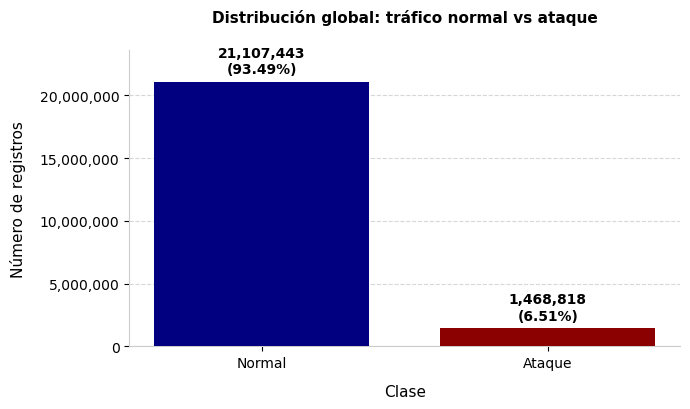

,attack_a,n,clase,porcentaje
0,0,21107443,Normal,93.493971
1,1,1468818,Ataque,6.506029


In [51]:
import matplotlib.pyplot as plt
global_counts = df_class_counts.groupby("attack_a", as_index=False)["n"].sum()
global_counts["clase"] = global_counts["attack_a"].map({0: "Normal", 1: "Ataque"})
global_counts["porcentaje"] = (global_counts["n"] / global_counts["n"].sum() * 100)

plt.rcParams['font.serif'] = ['Arial']
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams["axes.edgecolor"] = "#cccccc"
fig, ax = plt.subplots(figsize=(7, 4.2), dpi=100)

colores = ["#000080", "#8B0000"] 
bars = ax.bar(
    global_counts["clase"],
    global_counts["n"],
    color=colores,
    width=0.75,
    zorder=3,
)
ax.set_title(
    "Distribución global: tráfico normal vs ataque",
    fontsize=11,
    fontweight="bold",
    pad=20,
)
ax.set_xlabel("Clase", fontsize=11, labelpad=10)
ax.set_ylabel("Número de registros", fontsize=11, labelpad=10)
ax.set_ylim(0, global_counts["n"].max() * 1.12)
ax.get_yaxis().set_major_formatter(
    plt.FuncFormatter(lambda x, loc: f"{int(x):,}")
)
ax.grid(axis="y", linestyle="--", alpha=0.5, zorder=0)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

ax.spines["left"].set_color("#cccccc")
ax.spines["bottom"].set_color("#cccccc")

for bar, n, pct in zip(bars, global_counts["n"], global_counts["porcentaje"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height()
        + (global_counts["n"].max() * 0.02), 
        f"{n:,}\n({pct:.2f}%)",  # Reducido a 2 decimales para limpieza visual
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="semibold"
    )
plt.tight_layout()
plt.show()
global_counts

Gráfica 2: número de ataques por tipo específico - Segundo nivel de desbalance.

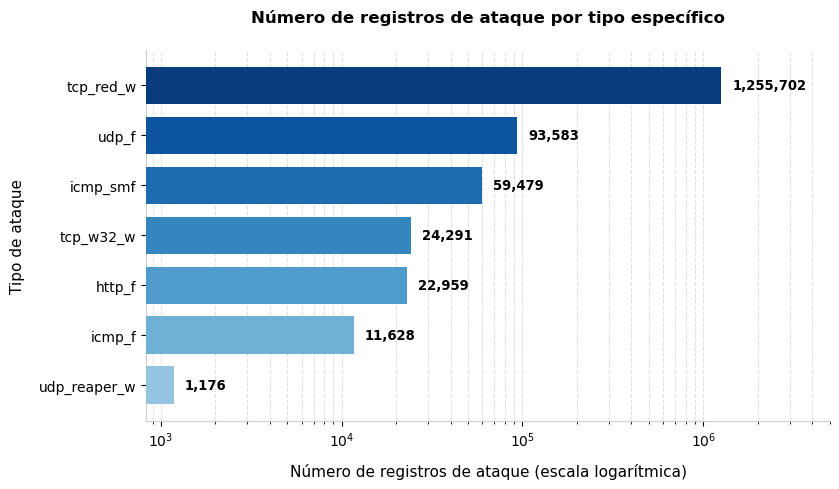

,attack_t,n
6,udp_reaper_w,1176
1,icmp_f,11628
0,http_f,22959
4,tcp_w32_w,24291
2,icmp_smf,59479
5,udp_f,93583
3,tcp_red_w,1255702


In [52]:
import matplotlib.cm as cm
attack_counts = (
    df_class_counts[df_class_counts["attack_t"] != "none"]
    .groupby("attack_t", as_index=False)["n"]
    .sum()
    .sort_values("n", ascending=True)
)
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams['font.serif'] = ['Arial']

fig, ax = plt.subplots(figsize=(8.5, 5), dpi=100)
num_barras = len(attack_counts)
colores_degradado = cm.Blues(np.linspace(0.4, 0.95, num_barras))

bars = ax.barh(attack_counts["attack_t"], attack_counts["n"], color=colores_degradado, height=0.75, zorder=3)
ax.set_xscale("log")

ax.set_title("Número de registros de ataque por tipo específico", fontsize=12, fontweight="bold", pad=20)
ax.set_xlabel("Número de registros de ataque (escala logarítmica)", fontsize=11, labelpad=10)
ax.set_ylabel("Tipo de ataque", fontsize=11, labelpad=10)
ax.set_xlim(right=attack_counts["n"].max() * 4)
ax.grid(axis="x", linestyle="--", alpha=0.4, zorder=0, which="both")

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

ax.spines["left"].set_color("#cccccc")
ax.spines["bottom"].set_color("#cccccc")

for bar, n in zip(bars, attack_counts["n"]):
    pos_x = bar.get_width() * 1.15
    ax.text(
        pos_x,
        bar.get_y() + bar.get_height() / 2,
        f"{n:,}",
        va="center",
        ha="left",
        fontsize=9.5,
        fontweight="semibold",
    )
plt.tight_layout()
plt.show()
attack_counts

### Análisis descriptivo de las variables númericas principales

In [3]:
from pathlib import Path
import duckdb
import pandas as pd

parquet_path = (PROCESSED_PATH / "dataset_unificado_renombrado.parquet").resolve()
# Directorio temporal para DuckDB.
DUCKDB_TEMP_PATH = Path("../data/interim/duckdb_tmp").resolve()
DUCKDB_TEMP_PATH.mkdir(parents=True, exist_ok=True)

parquet_sql_path = (
    parquet_path
    .as_posix()
    .replace("'", "''")
)
temp_sql_path = (
    DUCKDB_TEMP_PATH
    .as_posix()
    .replace("'", "''")
)
con = duckdb.connect()
con.execute("SET memory_limit = '6GB'")
con.execute("SET threads = 6")
con.execute(
    f"SET temp_directory = '{temp_sql_path}'"
)
print("DuckDB configurado correctamente.")
print(f"Parquet: {parquet_path}")
print(f"Temporal: {DUCKDB_TEMP_PATH}")

DuckDB configurado correctamente.
Parquet: C:\Users\Laura\Documents\TrabajoGrado2026\TG2026\data\processed\dataset_unificado_renombrado.parquet
Temporal: C:\Users\Laura\Documents\TrabajoGrado2026\TG2026\data\interim\duckdb_tmp


In [4]:
# Variables principales
main_numeric_variables = [
    "td",
    "ipkt",
    "ibyt",
]
# Orden deseado para las clases
CLASS_ORDER = [
    "normal",
    "icmp_f",
    "icmp_smf",
    "udp_f",
    "http_f",
    "tcp_w32_w",
    "tcp_red_w",
    "udp_reaper_w",
]

In [ ]:
def calculate_descriptive_summary(connection, variable, parquet_path_sql):
    """Calcula estadísticas descriptivas de una variable numérica sobre el Parquet completo, agrupando entre tráfico normal
    y cada tipo específico de ataque.
    """
    allowed_variables = {
        "td",
        "ipkt",
        "ibyt",
    }
    if variable not in allowed_variables:
        raise ValueError(
            f"Variable no permitida: {variable}"
        )
    query = f"""
    WITH base AS (
        SELECT
            CASE
                WHEN attack_a = 0 THEN 'normal'
                ELSE attack_t
            END AS clase,
            CAST("{variable}" AS DOUBLE) AS x
        FROM read_parquet('{parquet_path_sql}')
        WHERE "{variable}" IS NOT NULL
    ),
    resumen AS (
        SELECT
            clase,
            COUNT(*) AS n,
            MIN(x) AS minimo,
            AVG(x) AS media,
            quantile_cont(
                x,
                [
                    0.25,
                    0.50,
                    0.75,
                    0.90,
                    0.95,
                    0.99,
                    0.999
                ]
            ) AS cuantiles,
            MAX(x) AS maximo,
            SUM(
                CASE
                    WHEN x = 0 THEN 1
                    ELSE 0
                END
            ) AS n_ceros
        FROM base
        GROUP BY clase
    )
    SELECT
        clase,
        n,
        minimo,
        media,
        cuantiles[1] AS q1,
        cuantiles[2] AS mediana,
        cuantiles[3] AS q3,
        cuantiles[3] - cuantiles[1] AS iqr,
        cuantiles[4] AS p90,
        cuantiles[5] AS p95,
        cuantiles[6] AS p99,
        cuantiles[7] AS p99_9,
        maximo,
        n_ceros,
        100.0 * n_ceros / n AS porcentaje_ceros
    FROM resumen
    """
    df_result = connection.execute(
        query
    ).df()

    df_result["clase"] = pd.Categorical(
        df_result["clase"],
        categories=CLASS_ORDER,
        ordered=True,
    )
    df_result = (
        df_result
        .sort_values("clase")
        .reset_index(drop=True)
    )
    return df_result

In [ ]:
print("Calculando estadísticas de td sobre el dataset completo...")
df_summary_td = calculate_descriptive_summary(
    connection=con,
    variable="td",
    parquet_path_sql=parquet_sql_path,
)
df_summary_td

Calculando estadísticas de td sobre el dataset completo...


,clase,n,minimo,media,q1,mediana,q3,iqr,p90,p95,p99,p99_9,maximo,n_ceros,porcentaje_ceros
0,normal,21107443,0.0,5.295648,0.0,0.0,0.58,0.58,18.0000,45.0000,62.330002,87.699997,1798.215942,13058008.0,61.864471
1,icmp_f,11628,0.0,0.642141,0.0,0.0,0.32,0.32,1.6832,3.5200,11.328000,15.855744,18.496000,8237.0,70.837633
2,icmp_smf,59479,0.0,0.649261,0.0,0.0,0.00,0.00,1.8560,4.9344,10.304000,12.736000,14.656000,45461.0,76.432018
3,udp_f,93583,0.0,0.722520,0.0,0.0,0.00,0.00,0.0000,0.0000,35.660000,57.730000,61.090000,91362.0,97.626706
4,http_f,22959,0.0,2.243389,0.0,0.0,0.07,0.07,0.2700,18.0920,53.830002,61.621259,63.959999,12527.0,54.562481
5,tcp_w32_w,24291,0.0,0.000715,0.0,0.0,0.00,0.00,0.0000,0.0100,0.010000,0.050000,0.240000,23011.0,94.730559
6,tcp_red_w,1255702,0.0,6.545561,0.0,0.0,8.51,8.51,28.0000,30.6600,42.200001,90.400002,135.610001,745363.0,59.358271
7,udp_reaper_w,1176,0.0,0.000281,0.0,0.0,0.00,0.00,0.0000,0.0000,0.010000,0.020000,0.030000,1147.0,97.534014


In [ ]:
print("Calculando estadísticas de ipkt sobre el dataset completo...")
df_summary_ipkt = calculate_descriptive_summary(
    connection=con,
    variable="ipkt",
    parquet_path_sql=parquet_sql_path,
)
df_summary_ipkt

Calculando estadísticas de ipkt sobre el dataset completo...


,clase,n,minimo,media,q1,mediana,q3,iqr,p90,p95,p99,p99_9,maximo,n_ceros,porcentaje_ceros
0,normal,21107443,1.0,39.949787,2.0,5.0,10.0,8.0,20.0,42.0,390.00,5837.558,1468850.0,0.0,0.0
1,icmp_f,11628,1.0,3.312951,1.0,1.0,2.0,1.0,6.0,12.0,38.73,110.000,323.0,0.0,0.0
2,icmp_smf,59479,1.0,1.628877,1.0,1.0,2.0,1.0,3.0,4.0,8.00,14.000,60.0,0.0,0.0
3,udp_f,93583,2.0,2.048941,2.0,2.0,2.0,0.0,2.0,2.0,4.00,4.000,8.0,0.0,0.0
4,http_f,22959,5.0,8.465090,5.0,5.0,10.0,5.0,15.0,15.0,20.00,30.000,40.0,0.0,0.0
5,tcp_w32_w,24291,5.0,11.976246,5.0,5.0,5.0,0.0,5.0,100.0,145.00,175.000,210.0,0.0,0.0
6,tcp_red_w,1255702,5.0,7.844441,5.0,5.0,10.0,5.0,15.0,15.0,20.00,35.000,1355.0,0.0,0.0
7,udp_reaper_w,1176,2.0,5.887755,2.0,2.0,2.0,0.0,2.0,2.0,126.50,135.650,142.0,0.0,0.0


In [8]:
print(
    "Calculando estadísticas de ibyt "
    "sobre el dataset completo..."
)
df_summary_ibyt = calculate_descriptive_summary(
    connection=con,
    variable="ibyt",
    parquet_path_sql=parquet_sql_path,
)
df_summary_ibyt

Calculando estadísticas de ibyt sobre el dataset completo...


,clase,n,minimo,media,q1,mediana,q3,iqr,p90,p95,p99,p99_9,maximo,n_ceros,porcentaje_ceros
0,normal,21107443,28.0,33587.091921,200.0,220.0,895.0,695.0,5759.0,12730.0,199388.32,6272548.424,2.203254e+09,0.0,0.0
1,icmp_f,11628,46.0,190.738734,56.0,80.0,112.0,56.0,336.0,672.0,2168.88,6160.000,1.808800e+04,0.0,0.0
2,icmp_smf,59479,46.0,260.124851,129.0,182.0,294.0,165.0,489.0,694.0,1235.22,2139.000,1.196000e+04,0.0,0.0
3,udp_f,93583,112.0,197.759871,162.0,184.0,232.0,70.0,236.0,238.0,466.00,544.000,9.460000e+02,0.0,0.0
4,http_f,22959,200.0,659.390435,260.0,500.0,1035.0,775.0,1395.0,1575.0,2055.00,2890.840,4.305000e+03,0.0,0.0
5,tcp_w32_w,24291,200.0,479.049854,200.0,200.0,200.0,0.0,200.0,4000.0,5800.00,7000.000,8.400000e+03,0.0,0.0
6,tcp_red_w,1255702,200.0,345.074126,220.0,220.0,440.0,220.0,660.0,660.0,880.00,1540.000,5.962000e+04,0.0,0.0
7,udp_reaper_w,1176,80.0,235.510204,80.0,80.0,80.0,0.0,80.0,80.0,5060.00,5426.000,5.680000e+03,0.0,0.0


In [10]:
df_summary_td_complete = (df_summary_td
    .assign(variable="td")
)
df_summary_ipkt_complete = (df_summary_ipkt
    .assign(variable="ipkt")
)
df_summary_ibyt_complete = (df_summary_ibyt
    .assign(variable="ibyt")
)
df_main_numeric_summary = pd.concat(
    [
        df_summary_td_complete,
        df_summary_ipkt_complete,
        df_summary_ibyt_complete,
    ],
    ignore_index=True,
)
columns_order = ["variable", "clase", "n", "minimo", "media", "q1", "mediana", "q3", "iqr", "p90", "p95", "p99", "p99_9", "maximo", "n_ceros", "porcentaje_ceros",]
df_main_numeric_summary = (
    df_main_numeric_summary[
        columns_order
    ]
)
df_main_numeric_summary

,variable,clase,n,minimo,media,q1,mediana,q3,iqr,p90,p95,p99,p99_9,maximo,n_ceros,porcentaje_ceros
0,td,normal,21107443,0.0,5.295648,0.0,0.0,0.58,0.58,18.0000,45.0000,62.330002,8.770000e+01,1.798216e+03,13058008.0,61.864471
1,td,icmp_f,11628,0.0,0.642141,0.0,0.0,0.32,0.32,1.6832,3.5200,11.328000,1.585574e+01,1.849600e+01,8237.0,70.837633
2,td,icmp_smf,59479,0.0,0.649261,0.0,0.0,0.00,0.00,1.8560,4.9344,10.304000,1.273600e+01,1.465600e+01,45461.0,76.432018
3,td,udp_f,93583,0.0,0.722520,0.0,0.0,0.00,0.00,0.0000,0.0000,35.660000,5.773000e+01,6.109000e+01,91362.0,97.626706
4,td,http_f,22959,0.0,2.243389,0.0,0.0,0.07,0.07,0.2700,18.0920,53.830002,6.162126e+01,6.396000e+01,12527.0,54.562481
5,td,tcp_w32_w,24291,0.0,0.000715,0.0,0.0,0.00,0.00,0.0000,0.0100,0.010000,5.000000e-02,2.400000e-01,23011.0,94.730559
6,td,tcp_red_w,1255702,0.0,6.545561,0.0,0.0,8.51,8.51,28.0000,30.6600,42.200001,9.040000e+01,1.356100e+02,745363.0,59.358271
7,td,udp_reaper_w,1176,0.0,0.000281,0.0,0.0,0.00,0.00,0.0000,0.0000,0.010000,2.000000e-02,3.000000e-02,1147.0,97.534014
8,ipkt,normal,21107443,1.0,39.949787,2.0,5.0,10.00,8.00,20.0000,42.0000,390.000000,5.837558e+03,1.468850e+06,0.0,0.000000
9,ipkt,icmp_f,11628,1.0,3.312951,1.0,1.0,2.00,1.00,6.0000,12.0000,38.730000,1.100000e+02,3.230000e+02,0.0,0.000000


Las tres variables presentan distribuciones muy asimétricas, especialmente en tráfico normal y existen patrones bastante diferentes entre los distintos ataques.

- La duración del flujo (td) presentó una alta concentración de valores iguales a cero en todas las clases. Este comportamiento fue especialmente marcado en UDP Flood, Reaper Worm y Blaster Worm, con porcentajes de duración nula superiores al 94 %, mientras que Code Red mostró una mayor presencia de flujos prolongados. Por tanto, esta variable puede aportar información para diferenciar ataques caracterizados por comunicaciones prácticamente instantáneas de aquellos con conexiones de mayor duración.
- El número de paquetes de entrada (ipkt) presentó comportamientos diferenciados entre los ataques. UDP Flood y Smurf concentraron la mayoría de sus registros en cantidades muy bajas de paquetes, mientras que Blaster Worm y Reaper Worm mantuvieron valores típicos reducidos, pero presentaron una pequeña proporción de flujos con cantidades considerablemente mayores.
- Los bytes de entrada (ibyt) también mostraron diferencias entre los tipos de ataque. HTTP Flood presentó valores típicos superiores a varios de los demás ataques, mientras que UDP Flood mostró una distribución más concentrada. En Blaster Worm y Reaper Worm, la mayor parte de los registros presentó volúmenes reducidos, aunque los percentiles superiores evidenciaron un subconjunto de flujos con cantidades de bytes considerablemente mayores. 

Las tres variables presentaron distribuciones fuertemente asimétricas y diferencias considerables entre sus valores típicos y máximos. En el tráfico normal, por ejemplo, ipkt presentó una mediana de 5 paquetes frente a un máximo de 1.468.850, mientras que ibyt mostró una mediana de 220 bytes y un máximo superior a 2,2 × 10⁹ bytes. Por esta razón, durante la etapa de modelado se considerará el uso de transformaciones como log1p, especialmente en modelos sensibles a la escala y a valores extremos, como la Regresión Logística y el enfoque AE+LR. Esta transformación permite reducir la influencia de valores muy elevados conservando los registros con valor cero.

In [11]:
EDA_RESULTS_PATH = Path("../results/eda")
EDA_RESULTS_PATH.mkdir(parents=True, exist_ok=True)
summary_output_path = (EDA_RESULTS_PATH / "resumen_variables_principales_por_clase.csv")
df_main_numeric_summary.to_csv(summary_output_path, index=False, encoding="utf-8-sig",)
print("Resumen guardado en:")
print(summary_output_path)

Resumen guardado en:
..\results\eda\resumen_variables_principales_por_clase.csv


### Análisis de las variables de puertos ´sp´ y ´dp´

In [ ]:
# Distribución de protocolos por clase
query_protocols = f"""
WITH base AS (
    SELECT
        CASE
            WHEN attack_a = 0 THEN 'normal'
            ELSE attack_t
        END AS clase,
        pr
    FROM read_parquet('{parquet_sql_path}')
),
conteos AS (
    SELECT
        clase,
        pr,
        COUNT(*) AS n
    FROM base
    GROUP BY
        clase,
        pr
),
totales AS (
    SELECT
        clase,
        SUM(n) AS total_clase
    FROM conteos
    GROUP BY clase
)
SELECT
    c.clase,
    c.pr,
    c.n,
    100.0 * c.n / t.total_clase AS porcentaje
FROM conteos AS c
JOIN totales AS t
    ON c.clase = t.clase
ORDER BY
    c.clase,
    c.n DESC
"""
df_protocol_by_class = con.execute(query_protocols).df()
df_protocol_by_class["clase"] = pd.Categorical(df_protocol_by_class["clase"], categories=CLASS_ORDER, ordered=True)
df_protocol_by_class = (df_protocol_by_class
    .sort_values(
        ["clase", "n"],
        ascending=[True, False]
    )
    .reset_index(drop=True)
)
df_protocol_by_class

,clase,pr,n,porcentaje
0,normal,TCP,16198751,76.744260
1,normal,UDP,4543984,21.527875
2,normal,ICMP,282658,1.339139
3,normal,IPv6,35512,0.168244
4,normal,GRE,16723,0.079228
5,normal,ESP,15925,0.075447
6,normal,ICMP6,9852,0.046675
7,normal,AH,2949,0.013971
8,normal,OSPF,569,0.002696
9,normal,IGMP,239,0.001132


In [ ]:
# Función: puertos más frecuentes por clase y protocolo
def calculate_top_ports(connection, port_variable, parquet_path_sql, top_k=10):
    """
    Obtiene los puertos más frecuentes por clase y protocolo
    para las variables sp o dp. Solo se consideran registros TCP y UDP.
    """
    allowed_variables = {"sp", "dp"}
    if port_variable not in allowed_variables:
        raise ValueError(
            f"Variable no permitida: {port_variable}"
        )

    query = f"""
    WITH base AS (
        SELECT
            CASE
                WHEN attack_a = 0 THEN 'normal'
                ELSE attack_t
            END AS clase,
            pr,
            CAST("{port_variable}" AS BIGINT) AS puerto
        FROM read_parquet('{parquet_path_sql}')
        WHERE
            "{port_variable}" IS NOT NULL
            AND pr IN ('TCP', 'UDP')
    ),
    conteos AS (
        SELECT
            clase, pr, puerto, COUNT(*) AS n
        FROM base
        GROUP BY clase, pr, puerto
    ),
    totales AS (
        SELECT clase, pr, SUM(n) AS total_n
        FROM conteos
        GROUP BY clase, pr
    ),
    ranking AS (
        SELECT
            c.clase,
            c.pr,
            c.puerto,
            c.n,
            t.total_n,

            ROW_NUMBER() OVER (
                PARTITION BY
                    c.clase,
                    c.pr

                ORDER BY
                    c.n DESC,
                    c.puerto ASC
            ) AS ranking
        FROM conteos AS c
        JOIN totales AS t
            ON c.clase = t.clase
            AND c.pr = t.pr
    )
    SELECT
        clase,
        pr,
        ranking,
        puerto,
        n,
        100.0 * n / total_n AS porcentaje
    FROM ranking
    WHERE ranking <= {int(top_k)}
    ORDER BY clase, pr, ranking
    """

    df_result = connection.execute(query).df()
    df_result["clase"] = pd.Categorical(df_result["clase"], categories=CLASS_ORDER, ordered=True)
    df_result = (df_result
        .sort_values(
            [
                "clase",
                "pr",
                "ranking",
            ]
        )
        .reset_index(drop=True)
    )
    df_result["porcentaje_acumulado"] = (
        df_result
        .groupby(
            ["clase", "pr"],
            observed=True
        )["porcentaje"]
        .cumsum()
    )
    return df_result

In [ ]:
print("Calculando puertos de destino más frecuentes...")
df_top_dp = calculate_top_ports(connection=con, port_variable="dp", parquet_path_sql=parquet_sql_path, top_k=10)

In [ ]:
df_top_dp_5 = (df_top_dp[
        df_top_dp["ranking"] <= 5
    ]
    .copy()
)
df_top_dp_5

,clase,pr,ranking,puerto,n,porcentaje,porcentaje_acumulado
0,normal,TCP,1,443,3103632,19.159699,19.159699
1,normal,TCP,2,80,761137,4.698739,23.858438
2,normal,TCP,3,3389,147052,0.907798,24.766237
3,normal,TCP,4,23,101869,0.628869,25.395106
4,normal,TCP,5,445,63233,0.390357,25.785463
10,normal,UDP,1,53,1694988,37.301804,37.301804
11,normal,UDP,2,123,191052,4.204504,41.506308
12,normal,UDP,3,443,169270,3.725145,45.231453
13,normal,UDP,4,6881,35670,0.784994,46.016447
14,normal,UDP,5,37810,27747,0.610632,46.627079


In [ ]:
print("Calculando puertos de origen más frecuentes...")
df_top_sp = calculate_top_ports(connection=con, port_variable="sp", parquet_path_sql=parquet_sql_path, top_k=10)

In [ ]:
df_top_sp_5 = (df_top_sp[
        df_top_sp["ranking"] <= 5
    ]
    .copy()
)
df_top_sp_5

,clase,pr,ranking,puerto,n,porcentaje,porcentaje_acumulado
0,normal,TCP,1,443,3945369,24.356007,24.356007
1,normal,TCP,2,7547,738928,4.561636,28.917643
2,normal,TCP,3,22,631706,3.899720,32.817364
3,normal,TCP,4,80,604745,3.733282,36.550645
4,normal,TCP,5,5060,598087,3.692180,40.242825
10,normal,UDP,1,53,1437531,31.635917,31.635917
11,normal,UDP,2,443,211319,4.650523,36.286439
12,normal,UDP,3,123,106741,2.349062,38.635501
13,normal,UDP,4,37810,49001,1.078371,39.713872
14,normal,UDP,5,6881,32765,0.721063,40.434936


In [ ]:
# Función: concentración de puertos por clase y protocolo
def calculate_port_concentration(connection, port_variable, parquet_path_sql):
    """
    Calcula medidas de concentración de puertos para sp o dp,
    restringiendo el análisis a TCP y UDP.
    """
    allowed_variables = {"sp", "dp"}
    if port_variable not in allowed_variables:
        raise ValueError(
            f"Variable no permitida: {port_variable}"
        )

    query = f"""
    WITH base AS (
        SELECT
            CASE
                WHEN attack_a = 0 THEN 'normal'
                ELSE attack_t
            END AS clase,
            pr,
            CAST("{port_variable}" AS BIGINT) AS puerto
        FROM read_parquet('{parquet_path_sql}')
        WHERE
            "{port_variable}" IS NOT NULL
            AND pr IN ('TCP', 'UDP')
    ),
    conteos AS (
        SELECT
            clase,
            pr,
            puerto,
            COUNT(*) AS n
        FROM base
        GROUP BY
            clase,
            pr,
            puerto
    ),
    ranking AS (
        SELECT
            clase,
            pr,
            puerto,
            n,
            SUM(n) OVER (
                PARTITION BY
                    clase,
                    pr
            ) AS total_n,
            ROW_NUMBER() OVER (
                PARTITION BY
                    clase,
                    pr
                ORDER BY
                    n DESC,
                    puerto ASC
            ) AS ranking
        FROM conteos
    )
    SELECT
        clase,
        pr,
        MAX(total_n) AS n_registros,
        COUNT(*) AS n_puertos_unicos,
        MAX(
            CASE
                WHEN ranking = 1
                THEN puerto
            END
        ) AS puerto_dominante,
        MAX(
            CASE
                WHEN ranking = 1
                THEN n
            END
        ) AS n_puerto_dominante,
        100.0
        * SUM(
            CASE
                WHEN ranking <= 1
                THEN n
                ELSE 0
            END
        )
        / MAX(total_n) AS top1_pct,
        100.0
        * SUM(
            CASE
                WHEN ranking <= 3
                THEN n
                ELSE 0
            END
        )
        / MAX(total_n) AS top3_pct,
        100.0
        * SUM(
            CASE
                WHEN ranking <= 5
                THEN n
                ELSE 0
            END
        )
        / MAX(total_n) AS top5_pct,
        100.0
        * SUM(
            CASE
                WHEN ranking <= 10
                THEN n
                ELSE 0
            END
        )
        / MAX(total_n) AS top10_pct,
        100.0
        * SUM(
            CASE
                WHEN puerto = 0
                THEN n
                ELSE 0
            END
        )
        / MAX(total_n) AS puerto_cero_pct
    FROM ranking
    GROUP BY clase, pr
    ORDER BY clase, pr
    """
    df_result = connection.execute(query).df()
    df_result["clase"] = pd.Categorical(df_result["clase"], categories=CLASS_ORDER, ordered=True)
    df_result = (df_result
        .sort_values(
            ["clase", "pr"]
        )
        .reset_index(drop=True)
    )
    return df_result

In [ ]:
print("Calculando concentración de puertos de destino...")
df_concentration_dp = calculate_port_concentration(connection=con, port_variable="dp", parquet_path_sql=parquet_sql_path)
df_concentration_dp

Calculando concentración de puertos de destino...


,clase,pr,n_registros,n_puertos_unicos,puerto_dominante,n_puerto_dominante,top1_pct,top3_pct,top5_pct,top10_pct,puerto_cero_pct
0,normal,TCP,16198751.0,65525,443,3103632,19.159699,24.766237,25.785463,27.266571,0.003482
1,normal,UDP,4543984.0,65359,53,1694988,37.301804,45.231453,46.627079,48.790203,0.071303
2,udp_f,UDP,93583.0,1,53,93583,100.000000,100.000000,100.000000,100.000000,0.000000
3,http_f,TCP,22959.0,1,80,22959,100.000000,100.000000,100.000000,100.000000,0.000000
4,tcp_w32_w,TCP,24291.0,1,4444,24291,100.000000,100.000000,100.000000,100.000000,0.000000
5,tcp_red_w,TCP,1255702.0,64511,1677,63,0.005017,0.014335,0.023493,0.045473,0.000000
6,udp_reaper_w,TCP,1176.0,1,81,1176,100.000000,100.000000,100.000000,100.000000,0.000000


In [ ]:
print("Calculando concentración de puertos de origen...")
df_concentration_sp = calculate_port_concentration(connection=con, port_variable="sp", parquet_path_sql=parquet_sql_path)
df_concentration_sp

Calculando concentración de puertos de origen...


,clase,pr,n_registros,n_puertos_unicos,puerto_dominante,n_puerto_dominante,top1_pct,top3_pct,top5_pct,top10_pct,puerto_cero_pct
0,normal,TCP,16198751.0,65274,443,3945369,24.356007,32.817364,40.242825,50.940063,0.001303
1,normal,UDP,4543984.0,65516,53,1437531,31.635917,38.635501,40.434936,41.946164,0.070489
2,udp_f,UDP,93583.0,46531,22421,12,0.012823,0.038469,0.060908,0.114337,0.000000
3,http_f,TCP,22959.0,17239,58653,6,0.026134,0.069689,0.113245,0.209068,0.000000
4,tcp_w32_w,TCP,24291.0,1,56667,24291,100.000000,100.000000,100.000000,100.000000,0.000000
5,tcp_red_w,TCP,1255702.0,1,80,1255702,100.000000,100.000000,100.000000,100.000000,0.000000
6,udp_reaper_w,TCP,1176.0,1128,32893,2,0.170068,0.510204,0.850340,1.700680,0.000000


In [ ]:
df_sp_plot = (
    df_concentration_sp[df_concentration_sp["clase"] != "normal"][
        [
            "clase",
            "puerto_dominante",
            "top1_pct",
        ]
    ]
    .rename(
        columns={
            "puerto_dominante": "sp_dominante",
            "top1_pct": "sp_top1_pct",
        }
    )
)
df_dp_plot = (df_concentration_dp[df_concentration_dp["clase"] != "normal"][
        [
            "clase",
            "puerto_dominante",
            "top1_pct",
        ]
    ]
    .rename(
        columns={
            "puerto_dominante": "dp_dominante",
            "top1_pct": "dp_top1_pct",
        }
    )
)
df_port_plot = (df_sp_plot
    .merge(df_dp_plot, on="clase", how="inner")
)
CLASS_LABELS_PORTS = {
    "udp_f": "UDP Flood",
    "http_f": "HTTP Flood",
    "tcp_w32_w": "Blaster Worm",
    "tcp_red_w": "Code Red Worm",
    "udp_reaper_w": "Reaper Worm",
}
ATTACK_ORDER_PORTS = ["udp_f", "http_f", "tcp_w32_w", "tcp_red_w", "udp_reaper_w"]
df_port_plot["clase"] = (df_port_plot["clase"]
    .astype(str)
)
df_port_plot["clase_label"] = (df_port_plot["clase"]
    .map(CLASS_LABELS_PORTS)
)
df_port_plot["orden"] = (df_port_plot["clase"]
    .map({
        attack: i
        for i, attack in enumerate(ATTACK_ORDER_PORTS)
    })
)
df_port_plot = (df_port_plot
    .sort_values("orden")
    .reset_index(drop=True)
)
df_port_plot

,clase,sp_dominante,sp_top1_pct,dp_dominante,dp_top1_pct,clase_label,orden
0,udp_f,22421,0.012823,53,100.000000,UDP Flood,0
1,http_f,58653,0.026134,80,100.000000,HTTP Flood,1
2,tcp_w32_w,56667,100.000000,4444,100.000000,Blaster Worm,2
3,tcp_red_w,80,100.000000,1677,0.005017,Code Red Worm,3
4,udp_reaper_w,32893,0.170068,81,100.000000,Reaper Worm,4


### Correlación de Pearson global entre ipkt e ibyt

In [12]:
query_corr = f"""
WITH base AS (
    SELECT
        CASE WHEN attack_a = 0 THEN 'normal' ELSE attack_t END AS clase,
        CAST(ipkt AS DOUBLE) AS ipkt,
        CAST(ibyt AS DOUBLE) AS ibyt
    FROM read_parquet('{parquet_sql_path}')
)
SELECT
    clase,
    COUNT(*) AS n,
    corr(ipkt, ibyt) AS pearson_raw,
    corr(ln(1 + ipkt), ln(1 + ibyt)) AS pearson_log1p
FROM base
GROUP BY clase
ORDER BY clase
"""
df_corr_by_class = con.execute(query_corr).df()
df_corr_by_class["clase"] = pd.Categorical(df_corr_by_class["clase"], categories=CLASS_ORDER, ordered=True)
df_corr_by_class = (df_corr_by_class
    .sort_values("clase")
    .reset_index(drop=True)
)
df_corr_by_class

,clase,n,pearson_raw,pearson_log1p
0,normal,21107443,0.941543,0.853217
1,icmp_f,11628,0.999837,0.986100
2,icmp_smf,59479,0.874111,0.817568
3,udp_f,93583,0.748386,0.587426
4,http_f,22959,0.736457,0.760981
5,tcp_w32_w,24291,1.000000,0.999991
6,tcp_red_w,1255702,0.999884,0.999614
7,udp_reaper_w,1176,1.000000,0.999999


In [13]:
query_corr_global = f"""
SELECT
    COUNT(*) AS n,
    corr(CAST(ipkt AS DOUBLE), CAST(ibyt AS DOUBLE)) AS pearson_raw,
    corr(ln(1 + CAST(ipkt AS DOUBLE)), ln(1 + CAST(ibyt AS DOUBLE))) AS pearson_log1p
FROM read_parquet('{parquet_sql_path}')
"""
df_corr_global = con.execute(query_corr_global).df()
df_corr_global

,n,pearson_raw,pearson_log1p
0,22576261,0.941542,0.849798


Existe una relación positiva fuerte entre el número de paquetes de entrada y los bytes de entrada. Globalmente, la correlación de Pearson es de 0,9415, lo que indica que, en general, los flujos con más paquetes tienden también a acumular una mayor cantidad de bytes. Sin embargo, el tráfico normal representa aproximadamente el 93,49 % del conjunto de datos, por lo que la correlación global está fuertemente influenciada por esta clase. De hecho, la correlación global de 0,941542 es prácticamente idéntica a la del tráfico normal, que es 0,941543.

### EDA de banderas TCP normalizadas por clase

In [24]:
columns_to_read = (original_tcp_flag_columns + ["attack_a", "attack_t", "pr", "dataset_name"])
TCP_CLASS_ORDER = ["normal", "http_f", "tcp_w32_w", "tcp_red_w", "udp_reaper_w"]
FLAG_LABELS = {
    "tcp_flag_fin": "FIN",
    "tcp_flag_syn": "SYN",
    "tcp_flag_rst": "RST",
    "tcp_flag_psh": "PSH",
    "tcp_flag_ack": "ACK",
    "tcp_flag_urg": "URG",
    "tcp_flag_ece": "ECE",
    "tcp_flag_cwr": "CWR",
}
BATCH_SIZE = 100_000
total_tcp_by_class = Counter()
active_flags_by_class = {
    flag: Counter()
    for flag in normalized_tcp_flag_columns
}
combination_counts_by_class = {
    clase: Counter()
    for clase in TCP_CLASS_ORDER
}
format_counts = Counter()

In [25]:
def code_to_binary_string(code, n_bits=8):
    return "".join(
        "1" if code & (1 << i) else "0"
        for i in range(n_bits)
    )
def code_to_flag_label(code):
    active_names = [
        FLAG_LABELS[flag]
        for i, flag in enumerate(normalized_tcp_flag_columns)
        if code & (1 << i)
    ]
    if not active_names:
        return "NONE"
    return "+".join(active_names)

In [26]:
parquet_file = pq.ParquetFile(parquet_path)
total_rows = parquet_file.metadata.num_rows
rows_processed = 0
for batch_number, batch in enumerate(
    parquet_file.iter_batches(batch_size=BATCH_SIZE, columns=columns_to_read),
    start=1
):
    df_batch = batch.to_pandas()
    # Normaliza las seis columnas originales a ocho columnas binarias
    df_batch = normalize_tcp_flags(df_batch)

    df_batch["clase"] = np.where(df_batch["attack_a"].eq(0), "normal", df_batch["attack_t"])

    # Las banderas TCP solo se interpretan en registros TCP
    df_tcp = df_batch[df_batch["pr"].eq("TCP")].copy()
    df_tcp = df_tcp[df_tcp["clase"].isin(TCP_CLASS_ORDER)].copy()

    if not df_tcp.empty:
        total_tcp_by_class.update(df_tcp["clase"].value_counts().to_dict())

        # Activación de cada bandera por clase
        for flag in normalized_tcp_flag_columns:
            counts = (
                df_tcp
                .groupby("clase", observed=True)[flag]
                .sum()
                .astype(int)
                .to_dict()
            )
            active_flags_by_class[flag].update(counts)

        # Codificar combinación de banderas como entero de 8 bits
        codes = np.zeros(len(df_tcp), dtype=np.uint16)

        for i, flag in enumerate(normalized_tcp_flag_columns):
            codes |= (
                df_tcp[flag]
                .to_numpy(dtype=np.uint16)
                << i
            )
        df_tcp["_flag_code"] = codes

        combo_counts = (
            df_tcp
            .groupby(["clase", "_flag_code"], observed=True)
            .size()
        )
        for (clase, code), n in combo_counts.items():
            combination_counts_by_class[clase][int(code)] += int(n)

    rows_processed += batch.num_rows
    if batch_number % 25 == 0 or rows_processed == total_rows:
        print(f"Batch {batch_number} | "f"Filas procesadas: {rows_processed:,} / {total_rows:,}")
print("\nAnálisis de banderas TCP")

Batch 25 | Filas procesadas: 2,500,000 / 22,576,261
Batch 50 | Filas procesadas: 5,000,000 / 22,576,261
Batch 75 | Filas procesadas: 7,500,000 / 22,576,261
Batch 100 | Filas procesadas: 10,000,000 / 22,576,261
Batch 125 | Filas procesadas: 12,500,000 / 22,576,261
Batch 150 | Filas procesadas: 15,000,000 / 22,576,261
Batch 175 | Filas procesadas: 17,500,000 / 22,576,261
Batch 200 | Filas procesadas: 20,000,000 / 22,576,261
Batch 225 | Filas procesadas: 22,500,000 / 22,576,261
Batch 226 | Filas procesadas: 22,576,261 / 22,576,261

Análisis de banderas TCP


In [27]:
rows = []
for clase in TCP_CLASS_ORDER:
    total_clase = total_tcp_by_class[clase]
    if total_clase == 0:
        continue

    for flag in normalized_tcp_flag_columns:
        active_n = active_flags_by_class[flag][clase]
        rows.append({
            "clase": clase,
            "bandera": FLAG_LABELS[flag],
            "activa_n": active_n,
            "activa_pct": 100 * active_n / total_clase,
            "total_tcp_clase": total_clase,
        })
df_flag_activation_tcp = pd.DataFrame(rows)

df_flag_activation_tcp["clase"] = pd.Categorical(df_flag_activation_tcp["clase"], categories=TCP_CLASS_ORDER, ordered=True)
df_flag_activation_tcp = (df_flag_activation_tcp
    .sort_values(["clase", "bandera"])
    .reset_index(drop=True)
)
df_flag_activation_tcp

,clase,bandera,activa_n,activa_pct,total_tcp_clase
0,normal,ACK,10006946,61.776034,16198751
1,normal,CWR,74184,0.457961,16198751
2,normal,ECE,87600,0.540782,16198751
3,normal,FIN,1304255,8.051578,16198751
4,normal,PSH,4040470,24.943096,16198751
5,normal,RST,742221,4.581964,16198751
6,normal,SYN,9054482,55.896174,16198751
7,normal,URG,6,0.000037,16198751
8,http_f,ACK,18344,79.898950,22959
9,http_f,CWR,0,0.000000,22959


In [28]:
df_flag_activation_tcp_pivot = (
    df_flag_activation_tcp
    .pivot(index="clase", columns="bandera", values="activa_pct")
    .reset_index()
)
df_flag_activation_tcp_pivot["clase"] = pd.Categorical(df_flag_activation_tcp_pivot["clase"], categories=TCP_CLASS_ORDER, ordered=True)
df_flag_activation_tcp_pivot = (
    df_flag_activation_tcp_pivot
    .sort_values("clase")
    .reset_index(drop=True)
)
df_flag_activation_tcp_pivot

bandera,clase,ACK,CWR,ECE,FIN,PSH,RST,SYN,URG
0,normal,61.776034,0.457961,0.540782,8.051578,24.943096,4.581964,55.896174,0.000037
1,http_f,79.898950,0.000000,0.000000,29.147611,27.884490,26.725903,27.697199,0.000000
2,tcp_w32_w,0.000000,0.000000,0.000000,0.000000,0.000000,1.218558,99.011980,0.000000
3,tcp_red_w,99.893526,0.000239,0.000000,0.015688,0.000557,0.660826,99.645218,0.000000
4,udp_reaper_w,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,100.000000,0.000000


In [29]:
top_k = 10
combo_rows = []
for clase in TCP_CLASS_ORDER:
    total_clase = total_tcp_by_class[clase]
    if total_clase == 0:
        continue

    for ranking, (code, n) in enumerate(combination_counts_by_class[clase].most_common(top_k), start=1):
        combo_rows.append({
            "clase": clase,
            "ranking": ranking,
            "combinacion_binaria": code_to_binary_string(code),
            "combinacion": code_to_flag_label(code),
            "n": n,
            "porcentaje": 100 * n / total_clase,
        })
df_top_flag_combinations_tcp = pd.DataFrame(combo_rows)
df_top_flag_combinations_tcp["clase"] = pd.Categorical(df_top_flag_combinations_tcp["clase"], categories=TCP_CLASS_ORDER, ordered=True)

df_top_flag_combinations_tcp = (
    df_top_flag_combinations_tcp
    .sort_values(["clase", "ranking"])
    .reset_index(drop=True)
)
df_top_flag_combinations_tcp

,clase,ranking,combinacion_binaria,combinacion,n,porcentaje
0,normal,1,01001000,SYN+ACK,4145200,25.589627
1,normal,2,01000000,SYN,3541023,21.859852
2,normal,3,00011000,PSH+ACK,2387149,14.736624
3,normal,4,00000000,NONE,2258874,13.944742
4,normal,5,00001000,ACK,1027808,6.344983
5,normal,6,01011000,SYN+PSH+ACK,713766,4.406303
6,normal,7,10011000,FIN+PSH+ACK,487218,3.007750
7,normal,8,10001000,FIN+ACK,470826,2.906557
8,normal,9,11011000,FIN+SYN+PSH+ACK,250433,1.546002
9,normal,10,00100000,RST,194814,1.202648


In [30]:
EDA_RESULTS_PATH = Path("../results/eda")
EDA_RESULTS_PATH.mkdir(parents=True, exist_ok=True)
df_flag_activation_tcp.to_csv(EDA_RESULTS_PATH / "activacion_banderas_tcp_por_clase.csv", index=False, encoding="utf-8-sig")
df_top_flag_combinations_tcp.to_csv(EDA_RESULTS_PATH / "combinaciones_banderas_tcp_por_clase.csv", index=False, encoding="utf-8-sig")

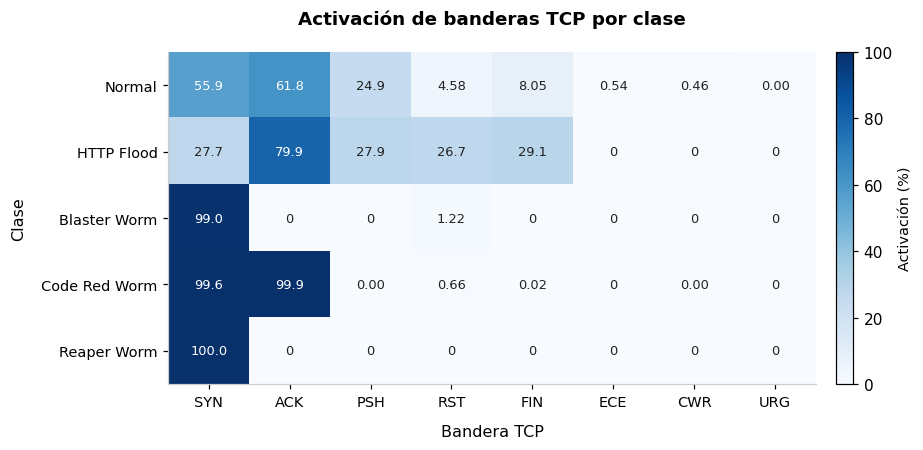

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
# Matriz de calor: activación de banderas TCP por clase
flag_order = ["SYN", "ACK", "PSH", "RST", "FIN", "ECE", "CWR", "URG"]
class_labels_tcp = {
    "normal": "Normal",
    "http_f": "HTTP Flood",
    "tcp_w32_w": "Blaster Worm",
    "tcp_red_w": "Code Red Worm",
    "udp_reaper_w": "Reaper Worm",
}
df_flags_heatmap = (
    df_flag_activation_tcp_pivot
    .copy()
)

df_flags_heatmap["clase_label"] = (
    df_flags_heatmap["clase"]
    .astype(str)
    .map(class_labels_tcp)
)

df_flags_heatmap = (
    df_flags_heatmap
    .set_index("clase_label")[flag_order]
)
values = df_flags_heatmap.values
plt.rcParams["font.family"] = "sans-serif"
fig, ax = plt.subplots(figsize=(8.5, 4.2), dpi=110)

im = ax.imshow(values, cmap=cm.Blues, aspect="auto", vmin=0, vmax=100)
ax.set_title("Activación de banderas TCP por clase", fontsize=12, fontweight="bold", pad=18)
ax.set_xlabel("Bandera TCP", fontsize=10.5, labelpad=10)
ax.set_ylabel("Clase", fontsize=10.5, labelpad=10)

ax.set_xticks(np.arange(len(flag_order)))
ax.set_xticklabels(flag_order, fontsize=9.5)

ax.set_yticks(np.arange(len(df_flags_heatmap.index)))
ax.set_yticklabels(df_flags_heatmap.index, fontsize=9.5)

for i in range(values.shape[0]):
    for j in range(values.shape[1]):
        value = values[i, j]
        if value >= 10:
            label = f"{value:.1f}"
        elif value > 0:
            label = f"{value:.2f}"
        else:
            label = "0"

        text_color = "white" if value >= 55 else "#222222"
        ax.text(j, i, label, ha="center", va="center", fontsize=8.5, color=text_color)

cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.03)
cbar.set_label("Activación (%)", fontsize=9.5)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

ax.spines["left"].set_color("#cccccc")
ax.spines["bottom"].set_color("#cccccc")
plt.tight_layout()
plt.show()

### Análisis de Variables Temporales

In [5]:
# Vista base ampliada para auditoría de variables temporales
con.execute(f"""
CREATE OR REPLACE TEMP VIEW v_temporal_base AS
SELECT
    dataset_name,
    attack_a,
    attack_t,
    CASE WHEN attack_a = 0 THEN 'normal' ELSE attack_t END AS clase,
    ts_year, ts_month, ts_day, ts_hour, ts_minute, ts_second,
    te_year, te_month, te_day, te_hour, te_minute, te_second,
    printf('%04d-%02d-%02d', ts_year, ts_month, ts_day) AS fecha,
    printf('%02d', ts_hour) AS hora,
    printf('%04d-%02d-%02d %02d:00', ts_year, ts_month, ts_day, ts_hour) AS fecha_hora,
    printf('%02d:%02d', ts_minute, ts_second) AS ts_mmss,
    printf('%02d:%02d', te_minute, te_second) AS te_mmss
FROM read_parquet('{parquet_sql_path}')
""")
print("Vista temporal ampliada creada correctamente.")

Vista temporal ampliada creada correctamente.


In [6]:
query_temporal_detail = """
SELECT
    clase,
    COUNT(*) AS n,
    COUNT(DISTINCT ts_minute) AS n_ts_minute,
    MIN(ts_minute) AS ts_min_min,
    MAX(ts_minute) AS ts_min_max,
    COUNT(DISTINCT ts_second) AS n_ts_second,
    MIN(ts_second) AS ts_sec_min,
    MAX(ts_second) AS ts_sec_max,
    COUNT(DISTINCT te_minute) AS n_te_minute,
    MIN(te_minute) AS te_min_min,
    MAX(te_minute) AS te_min_max,
    COUNT(DISTINCT te_second) AS n_te_second,
    MIN(te_second) AS te_sec_min,
    MAX(te_second) AS te_sec_max,
    COUNT(DISTINCT ts_mmss) AS n_ts_mmss,
    COUNT(DISTINCT te_mmss) AS n_te_mmss
FROM v_temporal_base
GROUP BY clase
ORDER BY clase
"""
df_temporal_detail = con.execute(query_temporal_detail).df()
df_temporal_detail["clase"] = pd.Categorical(df_temporal_detail["clase"], categories=CLASS_ORDER, ordered=True)
df_temporal_detail = df_temporal_detail.sort_values("clase").reset_index(drop=True)
df_temporal_detail

,clase,n,n_ts_minute,ts_min_min,ts_min_max,n_ts_second,ts_sec_min,ts_sec_max,n_te_minute,te_min_min,te_min_max,n_te_second,te_sec_min,te_sec_max,n_ts_mmss,n_te_mmss
0,normal,21107443,32,6,54,60,0,59,31,13,54,60,0,59,1618,1685
1,icmp_f,11628,6,34,39,60,0,59,6,34,39,60,0,59,299,299
2,icmp_smf,59479,6,34,39,60,0,59,6,34,39,60,0,59,299,300
3,udp_f,93583,6,13,18,60,0,59,7,13,19,60,0,59,301,351
4,http_f,22959,7,28,34,60,0,59,7,28,34,60,0,59,360,361
5,tcp_w32_w,24291,2,44,45,60,0,59,2,44,45,60,0,59,62,62
6,tcp_red_w,1255702,8,30,37,60,0,59,7,31,37,60,0,59,345,370
7,udp_reaper_w,1176,6,48,53,60,0,59,6,48,53,60,0,59,291,291


In [7]:
def calculate_temporal_component_concentration(variable):
    allowed = {"ts_minute", "ts_second", "te_minute", "te_second", "ts_mmss", "te_mmss"}
    if variable not in allowed:
        raise ValueError(f"Variable temporal no permitida: {variable}")
    query = f"""
    WITH c AS ( SELECT clase, {variable} AS valor, COUNT(*) AS n
        FROM v_temporal_base
        GROUP BY clase, valor
    ),
    r AS ( SELECT *, SUM(n) OVER(PARTITION BY clase) AS total_n,
            COUNT(*) OVER(PARTITION BY clase) AS n_valores,
            ROW_NUMBER() OVER(PARTITION BY clase ORDER BY n DESC, valor ASC) AS ranking
        FROM c
    )
    SELECT '{variable}' AS variable, clase, MAX(total_n) AS n, MAX(n_valores) AS n_valores,
        MAX(CASE WHEN ranking = 1 THEN valor END) AS valor_dominante,
        100.0 * SUM(CASE WHEN ranking <= 1 THEN n ELSE 0 END) / MAX(total_n) AS top1_pct,
        100.0 * SUM(CASE WHEN ranking <= 3 THEN n ELSE 0 END) / MAX(total_n) AS top3_pct,
        100.0 * SUM(CASE WHEN ranking <= 5 THEN n ELSE 0 END) / MAX(total_n) AS top5_pct
    FROM r
    GROUP BY clase
    ORDER BY clase
    """
    df = con.execute(query).df()
    df["clase"] = pd.Categorical(df["clase"], categories=CLASS_ORDER, ordered=True)
    return df.sort_values("clase").reset_index(drop=True)

In [8]:
temporal_components = ["ts_minute", "ts_second", "te_minute", "te_second"]
df_temporal_component_concentration = pd.concat([calculate_temporal_component_concentration(col) for col in temporal_components], ignore_index=True)
df_temporal_component_concentration

,variable,clase,n,n_valores,valor_dominante,top1_pct,top3_pct,top5_pct
0,ts_minute,normal,21107443.0,32,35,9.150241,24.686292,37.250926
1,ts_minute,icmp_f,11628.0,6,35,24.939800,64.705882,99.389405
2,ts_minute,icmp_smf,59479.0,6,35,23.840347,63.277796,99.490577
3,ts_minute,udp_f,93583.0,6,16,22.587436,62.515628,99.499909
4,ts_minute,http_f,22959.0,7,33,25.754606,62.807614,90.060543
5,ts_minute,tcp_w32_w,24291.0,2,45,53.052571,100.000000,100.000000
6,ts_minute,tcp_red_w,1255702.0,8,35,19.779295,58.726911,94.073912
7,ts_minute,udp_reaper_w,1176.0,6,49,21.853741,64.030612,97.789116
8,ts_second,normal,21107443.0,60,20,2.047410,6.032986,9.874195
9,ts_second,icmp_f,11628.0,60,26,2.812178,7.490540,11.816305


In [9]:
df_temporal_mmss_concentration = pd.concat([calculate_temporal_component_concentration("ts_mmss"), calculate_temporal_component_concentration("te_mmss")], ignore_index=True)
df_temporal_mmss_concentration

,variable,clase,n,n_valores,valor_dominante,top1_pct,top3_pct,top5_pct
0,ts_mmss,normal,21107443.0,1618,35:33,0.257265,0.763020,1.248953
1,ts_mmss,icmp_f,11628.0,299,37:26,0.816993,2.296182,3.697970
2,ts_mmss,icmp_smf,59479.0,299,37:29,0.650650,1.916643,3.132198
3,ts_mmss,udp_f,93583.0,301,16:37,1.058953,2.793242,4.284966
4,ts_mmss,http_f,22959.0,360,32:51,1.045342,2.421708,3.732741
5,ts_mmss,tcp_w32_w,24291.0,62,45:13,3.869746,10.304228,15.890659
6,ts_mmss,tcp_red_w,1255702.0,345,33:20,0.840566,2.517715,4.177902
7,ts_mmss,udp_reaper_w,1176.0,291,49:55,1.105442,2.976190,4.676871
8,te_mmss,normal,21107443.0,1685,35:33,0.221628,0.653670,1.063232
9,te_mmss,icmp_f,11628.0,299,36:39,0.687994,2.055384,3.371173


In [15]:
# Cobertura temporal por dataset
query_temporal_dataset = """
SELECT dataset_name,
COUNT(*) AS n,
COUNT(DISTINCT fecha) AS n_fechas,
COUNT(DISTINCT hora) AS n_horas,
COUNT(DISTINCT fecha_hora) AS n_fecha_hora,
MIN(fecha_hora) AS inicio,
MAX(fecha_hora) AS fin
FROM v_temporal_base
GROUP BY dataset_name
ORDER BY n DESC
"""
df_temporal_by_dataset = con.execute(query_temporal_dataset).df()
df_temporal_by_dataset

,dataset_name,n,n_fechas,n_horas,n_fecha_hora,inicio,fin
0,RED_WORM_v2,5637310,1,1,1,2020-01-30 20:00,2020-01-30 20:00
1,REAPER_WORM_v2,4673030,1,1,1,2019-10-02 07:00,2019-10-02 07:00
2,ICMP_FLOOD_v2,4407202,1,1,1,2020-01-31 15:00,2020-01-31 15:00
3,HTTP_FLOOD_v2,4109117,1,1,1,2020-01-16 09:00,2020-01-16 09:00
4,BLASTER_WORM_v2,3119478,1,1,1,2020-01-25 03:00,2020-01-25 03:00
5,UDP_FLOOD_v2,630124,1,1,1,2019-03-06 21:00,2019-03-06 21:00


In [17]:
# Cobertura temporal por clase
query_temporal_class = """
SELECT clase,
COUNT(*) AS n,
COUNT(DISTINCT fecha) AS n_fechas,
COUNT(DISTINCT hora) AS n_horas,
COUNT(DISTINCT fecha_hora) AS n_fecha_hora,
MIN(fecha_hora) AS inicio,
MAX(fecha_hora) AS fin
FROM v_temporal_base
GROUP BY clase
ORDER BY n DESC
"""
df_temporal_by_class = con.execute(query_temporal_class).df()
df_temporal_by_class["clase"] = pd.Categorical(df_temporal_by_class["clase"], categories=CLASS_ORDER, ordered=True)
df_temporal_by_class = (
    df_temporal_by_class
    .sort_values("clase")
    .reset_index(drop=True)
)
df_temporal_by_class

,clase,n,n_fechas,n_horas,n_fecha_hora,inicio,fin
0,normal,21107443,6,6,6,2019-03-06 21:00,2020-01-31 15:00
1,icmp_f,11628,1,1,1,2020-01-31 15:00,2020-01-31 15:00
2,icmp_smf,59479,1,1,1,2020-01-31 15:00,2020-01-31 15:00
3,udp_f,93583,1,1,1,2019-03-06 21:00,2019-03-06 21:00
4,http_f,22959,1,1,1,2020-01-16 09:00,2020-01-16 09:00
5,tcp_w32_w,24291,1,1,1,2020-01-25 03:00,2020-01-25 03:00
6,tcp_red_w,1255702,1,1,1,2020-01-30 20:00,2020-01-30 20:00
7,udp_reaper_w,1176,1,1,1,2019-10-02 07:00,2019-10-02 07:00


In [18]:
# Concentración temporal por clase
def calculate_temporal_concentration(temporal_column):
    allowed_columns = {"fecha", "hora", "fecha_hora"}
    if temporal_column not in allowed_columns:
        raise ValueError(f"Columna temporal no permitida: {temporal_column}")

    query = f"""
    WITH c AS (
        SELECT clase, {temporal_column} AS valor, COUNT(*) AS n
        FROM v_temporal_base
        GROUP BY clase, valor
    ),
    r AS (
        SELECT *,
        SUM(n) OVER(PARTITION BY clase) AS total_n,
        COUNT(*) OVER(PARTITION BY clase) AS n_valores,
        ROW_NUMBER() OVER(PARTITION BY clase ORDER BY n DESC, valor ASC) AS ranking
        FROM c
    )
    SELECT clase,
    MAX(total_n) AS n,
    MAX(n_valores) AS n_valores,
    MAX(CASE WHEN ranking = 1 THEN valor END) AS valor_dominante,
    MAX(CASE WHEN ranking = 1 THEN n END) AS n_valor_dominante,
    100.0 * SUM(CASE WHEN ranking <= 1 THEN n ELSE 0 END) / MAX(total_n) AS top1_pct,
    100.0 * SUM(CASE WHEN ranking <= 3 THEN n ELSE 0 END) / MAX(total_n) AS top3_pct,
    100.0 * SUM(CASE WHEN ranking <= 5 THEN n ELSE 0 END) / MAX(total_n) AS top5_pct
    FROM r
    GROUP BY clase
    ORDER BY clase
    """
    df_result = con.execute(query).df()
    df_result["clase"] = pd.Categorical(df_result["clase"], categories=CLASS_ORDER, ordered=True)
    return (
        df_result
        .sort_values("clase")
        .reset_index(drop=True)
    )

In [19]:
df_temporal_concentration_fecha = calculate_temporal_concentration("fecha")
df_temporal_concentration_hora = calculate_temporal_concentration("hora")
df_temporal_concentration_fecha_hora = calculate_temporal_concentration("fecha_hora")

In [42]:
df_temporal_concentration_fecha

,clase,n,n_valores,valor_dominante,n_valor_dominante,top1_pct,top3_pct,top5_pct
0,normal,21107443.0,6,2019-10-02,4671854,22.133681,63.435239,97.458048
1,icmp_f,11628.0,1,2020-01-31,11628,100.000000,100.000000,100.000000
2,icmp_smf,59479.0,1,2020-01-31,59479,100.000000,100.000000,100.000000
3,udp_f,93583.0,1,2019-03-06,93583,100.000000,100.000000,100.000000
4,http_f,22959.0,1,2020-01-16,22959,100.000000,100.000000,100.000000
5,tcp_w32_w,24291.0,1,2020-01-25,24291,100.000000,100.000000,100.000000
6,tcp_red_w,1255702.0,1,2020-01-30,1255702,100.000000,100.000000,100.000000
7,udp_reaper_w,1176.0,1,2019-10-02,1176,100.000000,100.000000,100.000000


In [43]:
df_temporal_concentration_hora

,clase,n,n_valores,valor_dominante,n_valor_dominante,top1_pct,top3_pct,top5_pct
0,normal,21107443.0,6,07,4671854,22.133681,63.435239,97.458048
1,icmp_f,11628.0,1,15,11628,100.000000,100.000000,100.000000
2,icmp_smf,59479.0,1,15,59479,100.000000,100.000000,100.000000
3,udp_f,93583.0,1,21,93583,100.000000,100.000000,100.000000
4,http_f,22959.0,1,09,22959,100.000000,100.000000,100.000000
5,tcp_w32_w,24291.0,1,03,24291,100.000000,100.000000,100.000000
6,tcp_red_w,1255702.0,1,20,1255702,100.000000,100.000000,100.000000
7,udp_reaper_w,1176.0,1,07,1176,100.000000,100.000000,100.000000


In [44]:
df_temporal_concentration_fecha_hora

,clase,n,n_valores,valor_dominante,n_valor_dominante,top1_pct,top3_pct,top5_pct
0,normal,21107443.0,6,2019-10-02 07:00,4671854,22.133681,63.435239,97.458048
1,icmp_f,11628.0,1,2020-01-31 15:00,11628,100.000000,100.000000,100.000000
2,icmp_smf,59479.0,1,2020-01-31 15:00,59479,100.000000,100.000000,100.000000
3,udp_f,93583.0,1,2019-03-06 21:00,93583,100.000000,100.000000,100.000000
4,http_f,22959.0,1,2020-01-16 09:00,22959,100.000000,100.000000,100.000000
5,tcp_w32_w,24291.0,1,2020-01-25 03:00,24291,100.000000,100.000000,100.000000
6,tcp_red_w,1255702.0,1,2020-01-30 20:00,1255702,100.000000,100.000000,100.000000
7,udp_reaper_w,1176.0,1,2019-10-02 07:00,1176,100.000000,100.000000,100.000000


In [21]:
# Top valores temporales por clase
def calculate_top_temporal_values(temporal_column, top_k=5):
    allowed_columns = {"fecha", "hora", "fecha_hora"}

    if temporal_column not in allowed_columns:
        raise ValueError(f"Columna temporal no permitida: {temporal_column}")

    query = f"""
    WITH c AS (
        SELECT clase, {temporal_column} AS valor, COUNT(*) AS n
        FROM v_temporal_base
        GROUP BY clase, valor
    ),
    r AS (
        SELECT *,
        SUM(n) OVER(PARTITION BY clase) AS total_n,
        ROW_NUMBER() OVER(PARTITION BY clase ORDER BY n DESC, valor ASC) AS ranking
        FROM c
    )
    SELECT clase, ranking, valor, n, 100.0 * n / total_n AS porcentaje
    FROM r
    WHERE ranking <= {int(top_k)}
    ORDER BY clase, ranking
    """

    df_result = con.execute(query).df()

    df_result["clase"] = pd.Categorical(
        df_result["clase"],
        categories=CLASS_ORDER,
        ordered=True
    )

    return (
        df_result
        .sort_values(["clase", "ranking"])
        .reset_index(drop=True)
    )

In [46]:
df_top_fecha_hora_by_class = calculate_top_temporal_values(
    temporal_column="fecha_hora",
    top_k=5
)
df_top_fecha_hora_by_class

,clase,ranking,valor,n,porcentaje
0,normal,1,2019-10-02 07:00,4671854,22.133681
1,normal,2,2020-01-30 20:00,4381608,20.758592
2,normal,3,2020-01-31 15:00,4336095,20.542967
3,normal,4,2020-01-16 09:00,4086158,19.358849
4,normal,5,2020-01-25 03:00,3095187,14.663960
5,icmp_f,1,2020-01-31 15:00,11628,100.000000
6,icmp_smf,1,2020-01-31 15:00,59479,100.000000
7,udp_f,1,2019-03-06 21:00,93583,100.000000
8,http_f,1,2020-01-16 09:00,22959,100.000000
9,tcp_w32_w,1,2020-01-25 03:00,24291,100.000000


In [ ]:
df_temporal_thesis = (
    df_temporal_by_class[
        [
            "clase",
            "n",
            "n_fecha_hora",
            "inicio",
            "fin",
        ]
    ]
    .copy()
)
class_labels_temporal = {
    "normal": "Normal",
    "icmp_f": "ICMP Flood",
    "icmp_smf": "Smurf",
    "udp_f": "UDP Flood",
    "http_f": "HTTP Flood",
    "tcp_w32_w": "Blaster Worm",
    "tcp_red_w": "Code Red Worm",
    "udp_reaper_w": "Reaper Worm",
}
df_temporal_thesis["Clase"] = (
    df_temporal_thesis["clase"]
    .astype(str)
    .map(class_labels_temporal)
)
df_temporal_thesis["Ventana temporal"] = np.where(df_temporal_thesis["inicio"].eq(df_temporal_thesis["fin"]), df_temporal_thesis["inicio"],
    df_temporal_thesis["inicio"] + " a " + df_temporal_thesis["fin"]
)
df_temporal_thesis = df_temporal_thesis[
    [
        "Clase",
        "n",
        "n_fecha_hora",
        "Ventana temporal",
    ]
].rename(
    columns={
        "n": "Registros",
        "n_fecha_hora": "Fechas-hora distintas",
    }
)
df_temporal_thesis

,Clase,Registros,Fechas-hora distintas,Ventana temporal
0,Normal,21107443,6,2019-03-06 21:00 a 2020-01-31 15:00
1,ICMP Flood,11628,1,2020-01-31 15:00
2,Smurf,59479,1,2020-01-31 15:00
3,UDP Flood,93583,1,2019-03-06 21:00
4,HTTP Flood,22959,1,2020-01-16 09:00
5,Blaster Worm,24291,1,2020-01-25 03:00
6,Code Red Worm,1255702,1,2020-01-30 20:00
7,Reaper Worm,1176,1,2019-10-02 07:00


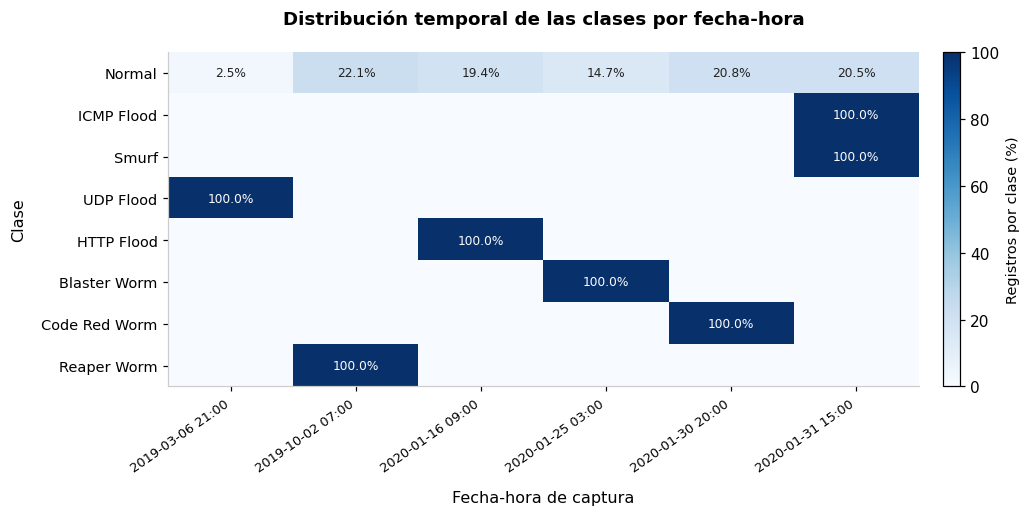

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
# Matriz temporal: distribución porcentual por fecha-hora
query_temporal_matrix = """
WITH c AS (
    SELECT clase, fecha_hora, COUNT(*) AS n
    FROM v_temporal_base
    GROUP BY clase, fecha_hora
),
t AS (
    SELECT clase, SUM(n) AS total_n
    FROM c
    GROUP BY clase
)
SELECT c.clase, c.fecha_hora, 100.0 * c.n / t.total_n AS porcentaje
FROM c
JOIN t ON c.clase = t.clase
ORDER BY c.clase, c.fecha_hora
"""
df_temporal_matrix = con.execute(query_temporal_matrix).df()
df_temporal_matrix["clase"] = pd.Categorical(df_temporal_matrix["clase"], categories=CLASS_ORDER, ordered=True)
df_temporal_matrix_pivot = (
    df_temporal_matrix
    .pivot(
        index="clase",
        columns="fecha_hora",
        values="porcentaje"
    )
    .fillna(0)
)

df_temporal_matrix_pivot = (
    df_temporal_matrix_pivot
    .reindex(CLASS_ORDER)
)
df_temporal_matrix_pivot.index = [
    class_labels_temporal[c]
    for c in df_temporal_matrix_pivot.index
]
values = df_temporal_matrix_pivot.values
plt.rcParams["font.family"] = "sans-serif"
fig, ax = plt.subplots(figsize=(9.5, 4.8), dpi=110)
im = ax.imshow(values, cmap=cm.Blues, aspect="auto", vmin=0, vmax=100)
ax.set_title("Distribución temporal de las clases por fecha-hora", fontsize=12, fontweight="bold", pad=18)
ax.set_xlabel("Fecha-hora de captura", fontsize=10.5, labelpad=10)
ax.set_ylabel("Clase", fontsize=10.5, labelpad=10)
ax.set_xticks(np.arange(len(df_temporal_matrix_pivot.columns)))
ax.set_xticklabels(df_temporal_matrix_pivot.columns, rotation=35, ha="right", fontsize=8.5)
ax.set_yticks(np.arange(len(df_temporal_matrix_pivot.index)))
ax.set_yticklabels(df_temporal_matrix_pivot.index, fontsize=9.5)

for i in range(values.shape[0]):
    for j in range(values.shape[1]):
        value = values[i, j]
        if value > 0:
            label = f"{value:.1f}%"
        else:
            label = ""

        text_color = "white" if value >= 55 else "#222222"
        ax.text(j, i, label, ha="center", va="center", fontsize=8, color=text_color)

cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.03)
cbar.set_label("Registros por clase (%)", fontsize=9.5)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

ax.spines["left"].set_color("#cccccc")
ax.spines["bottom"].set_color("#cccccc")
plt.tight_layout()
plt.show()

### Análisis de variables de alta cardinalidad y/o identificadores de red

In [26]:
entity_columns = ["sa", "da", "sas", "das", "in_if", "out_if"]
CLASS_LABELS_ENTITY = {
    "normal": "Normal",
    "icmp_f": "ICMP Flood",
    "icmp_smf": "Smurf",
    "udp_f": "UDP Flood",
    "http_f": "HTTP Flood",
    "tcp_w32_w": "Blaster Worm",
    "tcp_red_w": "Code Red Worm",
    "udp_reaper_w": "Reaper Worm",
}

In [27]:
def calculate_entity_concentration(variable):
    allowed = {"sa", "da", "sas", "das", "in_if", "out_if"}
    if variable not in allowed:
        raise ValueError(f"Variable no permitida: {variable}")

    query = f"""
    WITH c AS (
        SELECT CASE WHEN attack_a = 0 THEN 'normal' ELSE attack_t END AS clase,
        CAST({variable} AS VARCHAR) AS valor, COUNT(*) AS n
        FROM read_parquet('{parquet_sql_path}')
        GROUP BY clase, valor
    ),
    r AS (
        SELECT *, SUM(n) OVER(PARTITION BY clase) AS total_n,
        ROW_NUMBER() OVER(PARTITION BY clase ORDER BY n DESC, valor ASC) AS ranking
        FROM c
    )
    SELECT '{variable}' AS variable, clase, MAX(total_n) AS n_registros,
    COUNT(*) AS n_valores_unicos,
    MAX(CASE WHEN ranking = 1 THEN valor END) AS valor_dominante,
    MAX(CASE WHEN ranking = 1 THEN n END) AS n_valor_dominante,
    100.0 * SUM(CASE WHEN ranking <= 1 THEN n ELSE 0 END) / MAX(total_n) AS top1_pct,
    100.0 * SUM(CASE WHEN ranking <= 3 THEN n ELSE 0 END) / MAX(total_n) AS top3_pct,
    100.0 * SUM(CASE WHEN ranking <= 5 THEN n ELSE 0 END) / MAX(total_n) AS top5_pct,
    100.0 * SUM(CASE WHEN ranking <= 10 THEN n ELSE 0 END) / MAX(total_n) AS top10_pct
    FROM r
    GROUP BY clase
    ORDER BY clase
    """
    df = con.execute(query).df()
    df["clase"] = pd.Categorical(df["clase"], categories=CLASS_ORDER, ordered=True)
    return (
        df
        .sort_values(["variable", "clase"])
        .reset_index(drop=True)
    )

In [28]:
df_entity_concentration = pd.concat(
    [
        calculate_entity_concentration(variable)
        for variable in entity_columns
    ],
    ignore_index=True,
)
df_entity_concentration

,variable,clase,n_registros,n_valores_unicos,valor_dominante,n_valor_dominante,top1_pct,top3_pct,top5_pct,top10_pct
0,sa,normal,21107443.0,3127942,80.82.77.132,812849,3.851006,9.326274,12.181433,16.046202
1,sa,icmp_f,11628.0,1,193.219.95.2,11628,100.000000,100.000000,100.000000,100.000000
2,sa,icmp_smf,59479.0,3865,84.15.2.246,130,0.218565,0.497655,0.707813,1.183611
3,sa,udp_f,93583.0,8,195.10.208.2,19183,20.498381,56.784886,79.550773,100.000000
4,sa,http_f,22959.0,1,195.8.219.105,22959,100.000000,100.000000,100.000000,100.000000
5,sa,tcp_w32_w,24291.0,1,80.82.77.132,24291,100.000000,100.000000,100.000000,100.000000
6,sa,tcp_red_w,1255702.0,873211,24.197.214.202,24,0.001911,0.004539,0.006132,0.009636
7,sa,udp_reaper_w,1176.0,1,37.49.227.12,1176,100.000000,100.000000,100.000000,100.000000
8,da,normal,21107443.0,644342,193.219.81.138,3871868,18.343615,21.469498,22.533165,24.795727
9,da,icmp_f,11628.0,4900,141.98.11.12,144,1.238390,3.629171,5.959752,11.687307


In [29]:
df_entity_concentration_summary = (
    df_entity_concentration[
        ["variable", "clase", "n_registros", "n_valores_unicos", "valor_dominante", "top1_pct", "top10_pct"]
    ]
    .copy()
)
df_entity_concentration_summary["clase_label"] = (
    df_entity_concentration_summary["clase"]
    .astype(str)
    .map(CLASS_LABELS_ENTITY)
)
df_entity_concentration_summary = df_entity_concentration_summary[
    ["variable", "clase_label", "n_registros", "n_valores_unicos", "valor_dominante", "top1_pct", "top10_pct"]
]
df_entity_concentration_summary

,variable,clase_label,n_registros,n_valores_unicos,valor_dominante,top1_pct,top10_pct
0,sa,Normal,21107443.0,3127942,80.82.77.132,3.851006,16.046202
1,sa,ICMP Flood,11628.0,1,193.219.95.2,100.000000,100.000000
2,sa,Smurf,59479.0,3865,84.15.2.246,0.218565,1.183611
3,sa,UDP Flood,93583.0,8,195.10.208.2,20.498381,100.000000
4,sa,HTTP Flood,22959.0,1,195.8.219.105,100.000000,100.000000
5,sa,Blaster Worm,24291.0,1,80.82.77.132,100.000000,100.000000
6,sa,Code Red Worm,1255702.0,873211,24.197.214.202,0.001911,0.009636
7,sa,Reaper Worm,1176.0,1,37.49.227.12,100.000000,100.000000
8,da,Normal,21107443.0,644342,193.219.81.138,18.343615,24.795727
9,da,ICMP Flood,11628.0,4900,141.98.11.12,1.238390,11.687307


In [37]:
df_entity_concentration_summary.to_csv(EDA_RESULTS_PATH / "concentracion_variables_red_por_clase.csv", index=False, encoding="utf-8-sig")

La variable `sa` está completamente concentrada en una única dirección para ICMP Flood, HTTP Flood, Blaster Worm y Reaper Worm. En cambio, Code Red presenta una alta dispersión en origen, con más de 873.000 direcciones distintas, pero está completamente concentrado en una única dirección de destino (`da`). Algo similar ocurre con Smurf, que tiene destino único pero origen más disperso. UDP Flood presenta un comportamiento intermedio en la que tiene pocas direcciones de origen y una concentración importante en algunos destinos.

En las variables de sistemas autónomos (`sas`, `das`) también se observa concentración elevada. HTTP Flood, Blaster Worm y Reaper Worm tienen un único `sas`, mientras que varios ataques comparten o concentran el destino en `das` = 2847. Esto indica que estas variables resumen información de procedencia o destino de red que puede ser muy informativa, pero también dependiente de la infraestructura observada.

Las interfaces (`in_if`, `out_if`) muestran un comportamiento parecido, algunos ataques están completamente asociados con una interfaz específica, como HTTP Flood en `in_if` = 591 y `out_if` = 707, mientras que Code Red concentra el 92,63 % en `in_if` = 707 y el 100 % en `out_if` = 558.

## Preparación del conjunto de datos para modelado

En este notebook 02_unificacion_limpieza.ipynb: 
- Eliminación de variables constantes.
- Eliminación de identificadores de trazabilidad.
- Eliminación de variables temporales absolutas.
- Eliminación de las 19 variables generadas para reconocimiento de ataques.
- Normalización de banderas TCP de 6 columnas originales a 8 columnas binarias.
- Conservación de las etiquetas attack_a y attack_t.
- Conservación de dataset_name y attack_family como variables auxiliares, no predictoras.

In [22]:
pd.set_option("display.max_rows", None)
# Tabla de decisiones finales de preparación de variables
variable_decision_rows = []
for col in constant_columns:
    variable_decision_rows.append({
        "grupo": "Variables constantes",
        "variable": col,
        "decision": "Excluir",
        "motivo": "Sin variabilidad en el conjunto completo"
    })

for col in identifier_columns:
    variable_decision_rows.append({
        "grupo": "Identificadores",
        "variable": col,
        "decision": "Excluir",
        "motivo": "Variable de trazabilidad, no representa comportamiento del tráfico"
    })

for col in attack_recognition_columns:
    variable_decision_rows.append({
        "grupo": "Reconocimiento de ataques",
        "variable": col,
        "decision": "Excluir",
        "motivo": "Atributo generado para reconocimiento de ataques; posible fuga de información"
    })

for col in temporal_leakage_columns:
    variable_decision_rows.append({
        "grupo": "Variables temporales absolutas",
        "variable": col,
        "decision": "Excluir",
        "motivo": "Permite identificar la ventana de captura o el subconjunto de origen"
    })

for col in original_tcp_flag_columns:
    variable_decision_rows.append({
        "grupo": "Banderas TCP originales",
        "variable": col,
        "decision": "Reemplazar",
        "motivo": "Se normaliza a ocho banderas binarias TCP"
    })

for col in normalized_tcp_flag_columns:
    variable_decision_rows.append({
        "grupo": "Banderas TCP normalizadas",
        "variable": col,
        "decision": "Conservar",
        "motivo": "Representación binaria homogénea de las banderas TCP"
    })

for col in target_columns:
    variable_decision_rows.append({
        "grupo": "Variables objetivo",
        "variable": col,
        "decision": "Conservar",
        "motivo": "Etiqueta para tareas de clasificación"
    })

for col in auxiliary_columns:
    variable_decision_rows.append({
        "grupo": "Variables auxiliares",
        "variable": col,
        "decision": "Conservar como auxiliar",
        "motivo": "Útil para análisis, estratificación y evaluación, pero no como predictor"
    })

df_variable_decisions = pd.DataFrame(variable_decision_rows)
df_variable_decisions

,grupo,variable,decision,motivo
0,Variables constantes,fwd,Excluir,Sin variabilidad en el conjunto completo
1,Variables constantes,opkt,Excluir,Sin variabilidad en el conjunto completo
2,Variables constantes,obyt,Excluir,Sin variabilidad en el conjunto completo
3,Variables constantes,smk,Excluir,Sin variabilidad en el conjunto completo
4,Variables constantes,dmk,Excluir,Sin variabilidad en el conjunto completo
5,Variables constantes,dtos,Excluir,Sin variabilidad en el conjunto completo
6,Variables constantes,dir,Excluir,Sin variabilidad en el conjunto completo
7,Variables constantes,nh,Excluir,Sin variabilidad en el conjunto completo
8,Variables constantes,nhb,Excluir,Sin variabilidad en el conjunto completo
9,Variables constantes,svln,Excluir,Sin variabilidad en el conjunto completo


In [23]:
# Columnas a excluir del dataset preparado
columns_to_exclude_from_prepared = sorted(
    set(
        constant_columns
        + identifier_columns
        + attack_recognition_columns
        + temporal_leakage_columns
    )
)
print(
    f"Número de columnas a excluir: "
    f"{len(columns_to_exclude_from_prepared)}"
)
columns_to_exclude_from_prepared

Número de columnas a excluir: 64


['al',
 'cl',
 'dir',
 'dmk',
 'dtos',
 'dvln',
 'eng',
 'fwd',
 'icmp_dst_ip_b',
 'icmp_src_ip',
 'idmc',
 'ismc',
 'mpls1',
 'mpls10',
 'mpls2',
 'mpls3',
 'mpls4',
 'mpls5',
 'mpls6',
 'mpls7',
 'mpls8',
 'mpls9',
 'nh',
 'nhb',
 'obyt',
 'odmc',
 'opkt',
 'osmc',
 'p_range_dst',
 'ra',
 'record_id',
 'row_id_source',
 'sl',
 'smk',
 'smtp_dst',
 'svln',
 'tcp_dst_p',
 'tcp_dst_p_src',
 'tcp_f_n_a',
 'tcp_f_n_f',
 'tcp_f_n_p',
 'tcp_f_n_r',
 'tcp_f_n_u',
 'tcp_f_s',
 'tcp_src_dst_f_s',
 'tcp_src_kerb',
 'tcp_src_rpc',
 'tcp_src_tftp',
 'te_day',
 'te_hour',
 'te_minute',
 'te_month',
 'te_second',
 'te_year',
 'tr',
 'ts_day',
 'ts_hour',
 'ts_minute',
 'ts_month',
 'ts_second',
 'ts_year',
 'udp_dst_p',
 'udp_p_r_range',
 'udp_src_p_0']

88 columnas originales - 64 columnas excluidas - 6 banderas TCP originales + 8 banderas TCP normalizadas = 26 columnas finales

### **Crear dataset_unificado_preparado.parquet**

Este bloque lee el Parquet por lotes, normaliza las banderas, elimina las columnas acordadas y escribe el nuevo archivo sin cargar los 22 millones de registros completos en memoria.

In [24]:
# Crear dataset_unificado_preparado.parquet
import os
input_parquet_path = (
    PROCESSED_PATH
    / "dataset_unificado_renombrado.parquet"
)

prepared_parquet_path = (
    PROCESSED_PATH
    / "dataset_unificado_preparado.parquet"
)

temp_prepared_parquet_path = (
    PROCESSED_PATH
    / "dataset_unificado_preparado_tmp.parquet"
)
BATCH_SIZE = 100_000

# Evitar sobrescribir accidentalmente una versión previa
if temp_prepared_parquet_path.exists():
    temp_prepared_parquet_path.unlink()

parquet_file = pq.ParquetFile(input_parquet_path)
total_rows = parquet_file.metadata.num_rows
input_columns = parquet_file.schema_arrow.names

# Validaciones iniciales
missing_exclusion_columns = sorted(set(columns_to_exclude_from_prepared) - set(input_columns))
if missing_exclusion_columns:
    raise ValueError(
        "Hay columnas a excluir que no existen en el Parquet de entrada: "
        f"{missing_exclusion_columns}"
    )

missing_flag_columns = sorted(set(original_tcp_flag_columns) - set(input_columns))
if missing_flag_columns:
    raise ValueError(
        "Faltan columnas originales de banderas TCP: "
        f"{missing_flag_columns}"
    )

writer = None
rows_written = 0
final_schema = None

try:
    for batch_number, batch in enumerate(
        parquet_file.iter_batches(batch_size=BATCH_SIZE), start=1
    ):
        df_batch = batch.to_pandas()
        # 1. Normalizar banderas TCP: reemplaza las 6 columnas originales por 8 binarias
        df_batch = normalize_tcp_flags(df_batch)
        # 2. Eliminar variables acordadas
        df_batch = df_batch.drop(columns=columns_to_exclude_from_prepared, errors="ignore")

        # 3. Validar que no queden columnas duplicadas
        if df_batch.columns.duplicated().any():
            duplicated_columns = (
                df_batch.columns[
                    df_batch.columns.duplicated()
                ]
                .tolist()
            )
            raise ValueError(
                f"Columnas duplicadas después de preparar el batch: "
                f"{duplicated_columns}"
            )

        # 4. Convertir a tabla Arrow
        table = pa.Table.from_pandas(df_batch, preserve_index=False)
        # 5. Inicializar writer con el esquema del primer batch
        if writer is None:
            final_schema = table.schema
            writer = pq.ParquetWriter(where=temp_prepared_parquet_path, schema=final_schema, compression="snappy")
            print("Esquema final del dataset preparado:")
            print(final_schema)

        # 6. Validar que todos los batches tengan el mismo esquema
        if table.schema != final_schema:
            raise ValueError(
                f"El esquema del batch {batch_number} "
                "no coincide con el esquema inicial."
            )
        writer.write_table(table)
        rows_written += batch.num_rows
        if (
            batch_number % 25 == 0
            or rows_written == total_rows
        ):
            print(
                f"Batch {batch_number} | "
                f"Filas escritas: "
                f"{rows_written:,} / {total_rows:,}"
            )

finally:
    if writer is not None:
        writer.close()

# Validación de número de filas antes de reemplazar
prepared_file = pq.ParquetFile(temp_prepared_parquet_path)
prepared_rows = prepared_file.metadata.num_rows
prepared_columns = prepared_file.schema_arrow.names
if prepared_rows != total_rows:
    raise ValueError(
        f"El número de filas no coincide. "
        f"Entrada: {total_rows:,}, "
        f"Salida: {prepared_rows:,}"
    )

# Reemplazar versión final de forma segura
if prepared_parquet_path.exists():
    prepared_parquet_path.unlink()

os.replace(temp_prepared_parquet_path, prepared_parquet_path)
print("\nDataset preparado creado correctamente.")
print(f"Ruta: {prepared_parquet_path}")
print(f"Filas: {prepared_rows:,}")
print(f"Columnas: {len(prepared_columns)}")

Esquema final del dataset preparado:
td: float
sa: string
da: string
sp: int32
dp: int32
pr: string
tcp_flag_fin: int8
tcp_flag_syn: int8
tcp_flag_rst: int8
tcp_flag_psh: int8
tcp_flag_ack: int8
tcp_flag_urg: int8
tcp_flag_ece: int8
tcp_flag_cwr: int8
stos: int16
ipkt: int32
ibyt: int64
in_if: int16
out_if: int16
sas: int64
das: int64
exp: int8
attack_t: string
attack_a: int8
dataset_name: string
attack_family: string
-- schema metadata --
pandas: '{"index_columns": [], "column_indexes": [], "columns": [{"name":' + 2979
Batch 25 | Filas escritas: 2,500,000 / 22,576,261
Batch 50 | Filas escritas: 5,000,000 / 22,576,261
Batch 75 | Filas escritas: 7,500,000 / 22,576,261
Batch 100 | Filas escritas: 10,000,000 / 22,576,261
Batch 125 | Filas escritas: 12,500,000 / 22,576,261
Batch 150 | Filas escritas: 15,000,000 / 22,576,261
Batch 175 | Filas escritas: 17,500,000 / 22,576,261
Batch 200 | Filas escritas: 20,000,000 / 22,576,261
Batch 225 | Filas escritas: 22,500,000 / 22,576,261
Batch 226 | 

PermissionError: [WinError 32] El proceso no tiene acceso al archivo porque está siendo utilizado por otro proceso: '..\\data\\processed\\dataset_unificado_preparado_tmp.parquet' -> '..\\data\\processed\\dataset_unificado_preparado.parquet'

In [25]:
# Recuperar y renombrar archivo temporal preparado
import gc
import time
input_parquet_path = (PROCESSED_PATH / "dataset_unificado_renombrado.parquet")
prepared_parquet_path = (PROCESSED_PATH / "dataset_unificado_preparado.parquet")
temp_prepared_parquet_path = (PROCESSED_PATH / "dataset_unificado_preparado_tmp.parquet")
# Liberar posibles objetos que mantengan abierto el archivo
for object_name in ["prepared_file", "prepared_rows", "prepared_columns", "df_prepared_sample"]:
    if object_name in globals():
        del globals()[object_name]

gc.collect()
time.sleep(1)

# Verificar que el temporal existe
if not temp_prepared_parquet_path.exists():
    raise FileNotFoundError(
        f"No existe el archivo temporal: "
        f"{temp_prepared_parquet_path}"
    )
# Validar filas del archivo temporal
input_metadata = pq.read_metadata(input_parquet_path)
temp_metadata = pq.read_metadata(temp_prepared_parquet_path)
input_rows = input_metadata.num_rows
temp_rows = temp_metadata.num_rows
temp_columns = temp_metadata.schema.names
del input_metadata
del temp_metadata
gc.collect()
time.sleep(1)
print(f"Filas archivo original: {input_rows:,}")
print(f"Filas archivo temporal: {temp_rows:,}")
print(f"Columnas archivo temporal: {len(temp_columns)}")
if temp_rows != input_rows:
    raise ValueError(
        f"El número de filas no coincide. "
        f"Original: {input_rows:,}, temporal: {temp_rows:,}"
    )
# Eliminar versión final incompleta si existe
if prepared_parquet_path.exists():
    prepared_parquet_path.unlink()

gc.collect()
time.sleep(1)
# Intentar renombrar con varios intentos
for attempt in range(1, 6):
    try:
        os.replace(temp_prepared_parquet_path, prepared_parquet_path)
        print("\nArchivo renombrado correctamente.")
        break

    except PermissionError as error:
        print(
            f"Intento {attempt}: archivo aún bloqueado. "
            "Reintentando..."
        )
        gc.collect()
        time.sleep(2)

else:
    raise PermissionError(
        "No fue posible renombrar el archivo temporal. "
        "Cierra cualquier visor, explorador o proceso que pueda estar "
        "usando el archivo y vuelve a ejecutar esta celda."
    )
print(f"Ruta final: {prepared_parquet_path}")
print(f"Existe archivo final: {prepared_parquet_path.exists()}")
print(f"Existe temporal: {temp_prepared_parquet_path.exists()}")

Filas archivo original: 22,576,261
Filas archivo temporal: 22,576,261
Columnas archivo temporal: 26

Archivo renombrado correctamente.
Ruta final: ..\data\processed\dataset_unificado_preparado.parquet
Existe archivo final: True
Existe temporal: False


In [26]:
# Validación del dataset preparado
prepared_file = pq.ParquetFile(prepared_parquet_path)
prepared_rows = prepared_file.metadata.num_rows
prepared_columns = prepared_file.schema_arrow.names
print(f"Filas: {prepared_rows:,}")
print(f"Columnas: {len(prepared_columns)}")
print("\nColumnas finales:")
prepared_columns

Filas: 22,576,261
Columnas: 26

Columnas finales:


['td',
 'sa',
 'da',
 'sp',
 'dp',
 'pr',
 'tcp_flag_fin',
 'tcp_flag_syn',
 'tcp_flag_rst',
 'tcp_flag_psh',
 'tcp_flag_ack',
 'tcp_flag_urg',
 'tcp_flag_ece',
 'tcp_flag_cwr',
 'stos',
 'ipkt',
 'ibyt',
 'in_if',
 'out_if',
 'sas',
 'das',
 'exp',
 'attack_t',
 'attack_a',
 'dataset_name',
 'attack_family']

In [27]:
# Validaciones de columnas
excluded_still_present = sorted(set(columns_to_exclude_from_prepared) & set(prepared_columns))
missing_normalized_flags = sorted(set(normalized_tcp_flag_columns) - set(prepared_columns))
missing_targets = sorted(set(target_columns) - set(prepared_columns))
missing_auxiliary = sorted(set(auxiliary_columns) - set(prepared_columns))
print("Columnas excluidas que siguen presentes:")
print(excluded_still_present)
print("\nBanderas TCP normalizadas faltantes:")
print(missing_normalized_flags)
print("\nVariables objetivo faltantes:")
print(missing_targets)
print("\nVariables auxiliares faltantes:")
print(missing_auxiliary)

if excluded_still_present:
    raise ValueError(
        "Algunas columnas excluidas siguen presentes."
    )

if missing_normalized_flags:
    raise ValueError(
        "Faltan banderas TCP normalizadas."
    )

if missing_targets:
    raise ValueError(
        "Faltan variables objetivo."
    )

if missing_auxiliary:
    raise ValueError(
        "Faltan variables auxiliares."
    )
print("\nValidación de columnas completada correctamente.")

Columnas excluidas que siguen presentes:
[]

Banderas TCP normalizadas faltantes:
[]

Variables objetivo faltantes:
[]

Variables auxiliares faltantes:
[]

Validación de columnas completada correctamente.


In [28]:
# Vista rápida del dataset preparado
df_prepared_sample = pd.read_parquet(prepared_parquet_path, engine="pyarrow").head(10)
df_prepared_sample

,td,sa,da,sp,dp,pr,tcp_flag_fin,tcp_flag_syn,tcp_flag_rst,tcp_flag_psh,...,ibyt,in_if,out_if,sas,das,exp,attack_t,attack_a,dataset_name,attack_family
0,0.280000,193.219.74.172,83.169.5.121,59758,3306,TCP,1,0,0,1,...,1080,762,556,2847,8972,1,none,0,BLASTER_WORM_v2,worm
1,4.730000,184.73.156.247,193.219.75.85,443,58895,TCP,1,0,0,0,...,7300,707,588,14618,2847,1,none,0,BLASTER_WORM_v2,worm
2,0.000000,83.171.40.3,80.82.77.132,6666,56667,TCP,0,0,1,0,...,200,922,556,2847,202425,1,none,0,BLASTER_WORM_v2,worm
3,19.290001,95.108.213.17,158.129.192.240,62443,80,TCP,1,1,0,0,...,1080,556,558,13238,2847,1,none,0,BLASTER_WORM_v2,worm
4,1.820000,124.115.207.226,158.129.192.178,56637,33896,TCP,0,0,1,1,...,825,707,558,4134,2847,1,none,0,BLASTER_WORM_v2,worm
5,0.000000,80.82.77.132,158.129.192.215,56667,33389,TCP,0,0,1,0,...,200,707,558,202425,2847,1,none,0,BLASTER_WORM_v2,worm
6,0.930000,52.97.186.114,193.219.75.225,143,52165,TCP,0,0,1,1,...,3230,556,592,8075,2847,1,none,0,BLASTER_WORM_v2,worm
7,0.280000,64.179.209.3,193.219.165.4,53,54670,TCP,1,1,0,0,...,560,556,607,40224,2847,1,none,0,BLASTER_WORM_v2,worm
8,0.310000,193.219.163.162,47.246.2.227,58569,443,TCP,0,1,1,0,...,900,589,556,2847,24429,1,none,0,BLASTER_WORM_v2,worm
9,2.880000,193.219.36.204,180.244.234.201,22,33741,TCP,1,0,0,1,...,860,922,556,2847,7713,1,none,0,BLASTER_WORM_v2,worm


In [33]:
# Validar valores de las banderas TCP normalizadas
import duckdb
pd.set_option("display.max_columns", None)
prepared_sql_path = (prepared_parquet_path
    .resolve()
    .as_posix()
    .replace("'", "''")
)
flag_validation_exprs = []
for flag in normalized_tcp_flag_columns:
    flag_validation_exprs.append(
        f"MIN({flag}) AS min_{flag}"
    )
    flag_validation_exprs.append(
        f"MAX({flag}) AS max_{flag}"
    )
    flag_validation_exprs.append(
        f"SUM(CASE WHEN {flag} NOT IN (0, 1) THEN 1 ELSE 0 END) "
        f"AS invalid_{flag}"
    )

query_flag_validation = f"""
SELECT
{", ".join(flag_validation_exprs)}
FROM read_parquet('{prepared_sql_path}')
"""
df_flag_validation_prepared = con.execute(
    query_flag_validation
).df()
df_flag_validation_prepared

,min_tcp_flag_fin,max_tcp_flag_fin,invalid_tcp_flag_fin,min_tcp_flag_syn,max_tcp_flag_syn,invalid_tcp_flag_syn,min_tcp_flag_rst,max_tcp_flag_rst,invalid_tcp_flag_rst,min_tcp_flag_psh,max_tcp_flag_psh,invalid_tcp_flag_psh,min_tcp_flag_ack,max_tcp_flag_ack,invalid_tcp_flag_ack,min_tcp_flag_urg,max_tcp_flag_urg,invalid_tcp_flag_urg,min_tcp_flag_ece,max_tcp_flag_ece,invalid_tcp_flag_ece,min_tcp_flag_cwr,max_tcp_flag_cwr,invalid_tcp_flag_cwr
0,0,1,0.0,0,1,0.0,0,1,0.0,0,1,0.0,0,1,0.0,0,1,0.0,0,1,0.0,0,1,0.0


In [34]:
# Validar distribución de clases en dataset preparado
query_prepared_class_counts = f"""
SELECT
dataset_name,
attack_family,
attack_t,
attack_a,
COUNT(*) AS n
FROM read_parquet('{prepared_sql_path}')
GROUP BY dataset_name, attack_family, attack_t, attack_a
ORDER BY dataset_name, attack_a, attack_t
"""
df_prepared_class_counts = con.execute(
    query_prepared_class_counts
).df()
df_prepared_class_counts

,dataset_name,attack_family,attack_t,attack_a,n
0,BLASTER_WORM_v2,worm,none,0,3095187
1,BLASTER_WORM_v2,worm,tcp_w32_w,1,24291
2,HTTP_FLOOD_v2,flood,none,0,4086158
3,HTTP_FLOOD_v2,flood,http_f,1,22959
4,ICMP_FLOOD_v2,flood,none,0,4336095
5,ICMP_FLOOD_v2,flood,icmp_f,1,11628
6,ICMP_FLOOD_v2,flood,icmp_smf,1,59479
7,REAPER_WORM_v2,worm,none,0,4671854
8,REAPER_WORM_v2,worm,udp_reaper_w,1,1176
9,RED_WORM_v2,worm,none,0,4381608


In [ ]:
# Variables para el siguiente notebook de modelado
prepared_columns = pq.ParquetFile(prepared_parquet_path).schema_arrow.names
non_predictor_columns = (target_columns + auxiliary_columns)
predictor_candidate_columns = [
    col
    for col in prepared_columns
    if col not in non_predictor_columns
]
print(
    f"Número de columnas en dataset preparado: "
    f"{len(prepared_columns)}"
)
print(
    f"Número de predictoras candidatas: "
    f"{len(predictor_candidate_columns)}"
)
print("\nPredictoras candidatas:")
predictor_candidate_columns

Número de columnas en dataset preparado: 26
Número de predictoras candidatas: 22

Predictoras candidatas:


['td',
 'sa',
 'da',
 'sp',
 'dp',
 'pr',
 'tcp_flag_fin',
 'tcp_flag_syn',
 'tcp_flag_rst',
 'tcp_flag_psh',
 'tcp_flag_ack',
 'tcp_flag_urg',
 'tcp_flag_ece',
 'tcp_flag_cwr',
 'stos',
 'ipkt',
 'ibyt',
 'in_if',
 'out_if',
 'sas',
 'das',
 'exp']

A partir de los resultados del análisis exploratorio se generó una versión preparada del conjunto de datos. En esta versión se excluyeron las variables constantes, los identificadores de trazabilidad, las variables temporales absolutas y los atributos generados para reconocimiento de ataques, debido a su baja contribución informativa o al riesgo de inducir fuga de información. Además, las banderas TCP fueron normalizadas a ocho variables binarias para unificar las representaciones textual y hexadecimal encontradas en los datos. Se conservaron las variables objetivo (attack_a y attack_t) y las variables auxiliares (dataset_name y attack_family) para permitir la estratificación, el análisis posterior y la evaluación por subconjunto. Esta versión servirá como entrada para los notebooks de modelado, donde se definirán los esquemas de codificación, transformación, balanceo y entrenamiento específicos para cada algoritmo.